# EDA MILPÍN AgTech v2.0
**Valle del Yaqui, Sonora — Distrito de Riego DR-041**

| Sección | Contenido |
|---|---|
| 1. Vista General | Tablas, filas, nulos, dtypes |
| 2. Catálogo FAO-56 | Kc, Ky, duración de ciclo, rendimiento |
| 3. Parcelas | Suelo, riego, agua disponible, salinidad |
| 4. Recomendaciones | Urgencias, feedback del agricultor, motor FAO-56 |
| 5. KPI Hídrico | Volumen m³/ha vs baseline 8,000 · meta 6,000 |
| 6. Economía | Márgenes, estructura de costos, ROI hídrico |
| 7. Hallazgos Clave | Tabla resumen ejecutivo |

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# MILPÍN — Auto-guardado en ML/images/
# Generado por ML/patch_notebooks.py — NO editar manualmente.
# ═══════════════════════════════════════════════════════════════════
from pathlib import Path
import sys as _sys
import re  as _re
import atexit as _atexit

# ── Directorio de salida ─────────────────────────────────────────────────────
_here = Path().resolve()
IMAGES_DIR = (
    _here.parent / "images"
    if _here.name == "experiments"
    else _here / "ML" / "images"
)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

# ── Parche matplotlib: auto-save en plt.show() + redirigir plt.savefig ───────
import matplotlib.pyplot   as _plt
import matplotlib.figure   as _mpl_fig

_saved_fig_ids  = set()
_auto_fig_count = [0]
_orig_plt_show    = _plt.show
_orig_plt_savefig = _plt.savefig
_orig_fig_savefig = _mpl_fig.Figure.savefig

def _auto_fname(fig, n):
    title = (fig._suptitle.get_text() if fig._suptitle else "") or next(
        (ax.get_title() for ax in fig.get_axes() if ax.get_title()), "")
    stem = _re.sub(r"[^\w\-]", "_", title)[:50].strip("_").lower() if title else f"figura_{n:03d}"
    return f"{stem}.png"

def _patched_plt_savefig(fname, *a, **kw):
    dest = IMAGES_DIR / Path(str(fname)).name
    fig  = _plt.gcf()
    _orig_fig_savefig(fig, dest, *a, **kw)  # llama directo para evitar doble-parche
    _saved_fig_ids.add(id(fig))
    print(f"  ✓ [imagen] {dest.name}")

def _patched_fig_savefig(self, fname, *a, **kw):
    dest = IMAGES_DIR / Path(str(fname)).name
    _orig_fig_savefig(self, dest, *a, **kw)
    _saved_fig_ids.add(id(self))
    print(f"  ✓ [imagen] {dest.name}")

def _patched_plt_show(*a, **kw):
    fig = _plt.gcf()
    if fig.get_axes() and id(fig) not in _saved_fig_ids:
        _auto_fig_count[0] += 1
        fname = _auto_fname(fig, _auto_fig_count[0])
        _orig_fig_savefig(fig, IMAGES_DIR / fname, dpi=150, bbox_inches="tight")
        print(f"  ✓ [auto-imagen] {fname}")
    _saved_fig_ids.discard(id(fig))
    _orig_plt_show(*a, **kw)

_plt.show               = _patched_plt_show
_plt.savefig            = _patched_plt_savefig
_mpl_fig.Figure.savefig = _patched_fig_savefig

# ── Parche pandas: auto-save DataFrames al mostrarse en Jupyter ─────────────
_df_count = [0]
try:
    import pandas as _pd
    _orig_df_repr_html = _pd.DataFrame._repr_html_

    def _patched_df_repr_html(self):
        _df_count[0] += 1
        stem = f"tabla_{_df_count[0]:03d}"
        self.to_csv(IMAGES_DIR / f"{stem}.csv", index=True, encoding="utf-8-sig")
        self.to_html(IMAGES_DIR / f"{stem}.html")
        print(f"  ✓ [tabla] {stem}.csv  ({len(self)} filas × {len(self.columns)} cols)")
        return _orig_df_repr_html(self)

    _pd.DataFrame._repr_html_ = _patched_df_repr_html
except Exception as _pd_err:
    print(f"  ! pandas hook: {_pd_err}")

# ── Capturar stdout → IMAGES_DIR/output_log.txt ──────────────────────────────
_log_path = IMAGES_DIR / "output_log.txt"
_log_file = open(_log_path, "w", encoding="utf-8")

class _Tee:
    def __init__(self, real, log):
        self._real = real
        self._log  = log
    def write(self, s):
        self._real.write(s)
        self._log.write(s)
    def flush(self):
        self._real.flush()
        self._log.flush()
    def __getattr__(self, attr):
        return getattr(self._real, attr)

_sys.stdout = _Tee(_sys.__stdout__, _log_file)
_atexit.register(lambda: (_log_file.flush(), _log_file.close()))

print(f"✓ IMAGES_DIR  → {IMAGES_DIR}")
print(f"✓ matplotlib  → auto-save en show() + redirigir savefig()")
print(f"✓ pandas      → auto-save DataFrames (CSV + HTML)")
print(f"✓ stdout      → {_log_path.name}")


In [ ]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')

DATA_DIR = Path('..') / 'data' / 'synthetic'

# ── Paleta visual MILPÍN ─────────────────────────────────────────────────────
CULTIVO_COLORS = {
    'Maíz':    '#F4C430',
    'Frijol':  '#8B4513',
    'Algodón': '#5F9EA0',
    'Uva':     '#722F37',
    'Chile':   '#DC143C',
}
VERDE = '#27AE60'; NARANJA = '#E67E22'; ROJO = '#C0392B'; AZUL = '#2980B9'; GRIS = '#7F8C8D'
URGENCIA_COLORS = {'crítico': ROJO, 'moderado': NARANJA, 'preventivo': VERDE}

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 130, 'savefig.bbox': 'tight',
                     'axes.titlesize': 13, 'axes.labelsize': 11})

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_colwidth', 40)

---
## 1 · Vista General de las Tablas

In [ ]:
# Carga de los 6 datasets
usuarios  = pd.read_csv('../../data/synthetic/usuarios.csv')
cultivos  = pd.read_csv('../../data/synthetic/cultivos_catalogo.csv')
parcelas  = pd.read_csv('../../data/synthetic/parcelas.csv')
recomend  = pd.read_csv('../../data/synthetic/recomendaciones.csv')
historial = pd.read_csv('../../data/synthetic/historial_riego.csv')
costos    = pd.read_csv('../../data/synthetic/costos_ciclo.csv')

# Parsear fechas
recomend['fecha_generacion']  = pd.to_datetime(recomend['fecha_generacion'],  utc=True)
historial['fecha_riego']      = pd.to_datetime(historial['fecha_riego'])

# Enriquecer parcelas: unir cultivo desde costos (más fiable que parsear nombre_parcela)
cultivo_x_parcela = (
    costos.drop_duplicates('id_parcela')[['id_parcela', 'cultivo']]
)
parcelas = parcelas.merge(cultivo_x_parcela, on='id_parcela', how='left')

# Agua Disponible Total (mm) = (CC - PMP) × profundidad_raiz_cm × 10
parcelas['agua_disponible_mm'] = (
    (parcelas['capacidad_campo'] - parcelas['punto_marchitez'])
    * parcelas['profundidad_raiz_cm'] * 10
)

# ── Tabla resumen de datasets ─────────────────────────────────────────────────
dfs = {
    'usuarios':       usuarios,
    'cultivos_catalogo': cultivos,
    'parcelas':       parcelas,
    'recomendaciones': recomend,
    'historial_riego': historial,
    'costos_ciclo':   costos,
}

resumen = pd.DataFrame([
    {
        'Dataset': name,
        'Filas': df.shape[0],
        'Columnas': df.shape[1],
        'Nulos (total)': df.isnull().sum().sum(),
        'Nulos (%)': round(df.isnull().mean().mean() * 100, 1),
        'Memoria (KB)': round(df.memory_usage(deep=True).sum() / 1024, 1),
    }
    for name, df in dfs.items()
])

display(
    resumen.style
    .set_caption('📋 Inventario de datasets — MILPÍN v2.0')
    .background_gradient(subset=['Filas'], cmap='Blues')
    .background_gradient(subset=['Nulos (%)'], cmap='YlOrRd')
    .format({'Nulos (%)': '{:.1f}%', 'Memoria (KB)': '{:.1f} KB'})
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '14px'), ('font-weight', 'bold'), ('color', '#2C3E50')]
    }])
    .hide(axis='index')
)

Dataset,Filas,Columnas,Nulos (total),Nulos (%),Memoria (KB)
usuarios,20,7,0,0.0%,7.7 KB
cultivos_catalogo,5,12,0,0.0%,1.5 KB
parcelas,80,16,0,0.0%,65.6 KB
recomendaciones,20800,15,6362,2.0%,14312.1 KB
historial_riego,13427,14,18806,10.0%,6984.8 KB
costos_ciclo,800,13,0,0.0%,280.3 KB


In [ ]:
# Nulos detallados por columna (solo columnas con nulos)
nulos_por_df = {}
for name, df in dfs.items():
    s = df.isnull().sum()
    s = s[s > 0].rename(name)
    if not s.empty:
        nulos_por_df[name] = s

if nulos_por_df:
    nulos_df = pd.DataFrame(nulos_por_df).fillna(0).astype(int)
    display(
        nulos_df.style
        .set_caption(' Valores nulos por columna y dataset')
        .background_gradient(cmap='Oranges', axis=None)
        .format('{:,d}')
        .set_table_styles([{'selector': 'caption',
                            'props': [('font-size', '13px'), ('font-weight', 'bold')]}])
    )
else:
    print('✓ No hay valores nulos en ningún dataset.')

,recomendaciones,historial_riego
id_recomendacion,0,"5,379"
lamina_ejecutada_mm,"6,362",0
observaciones,0,"13,427"


---
## 2 · Catálogo de Cultivos — Parámetros FAO-56

In [ ]:
# Calcular métricas derivadas del catálogo
cult = cultivos.copy()
cult['ciclo_total_dias'] = (
    cult['dias_etapa_inicial'] + cult['dias_etapa_desarrollo']
    + cult['dias_etapa_media'] + cult['dias_etapa_final']
)
# Kc ponderado = 20% inicial + 60% medio + 20% final (pesos de duración aprox)
cult['kc_ponderado'] = (
    cult['kc_inicial'] * 0.20
    + cult['kc_medio']  * 0.60
    + cult['kc_final']  * 0.20
).round(3)
# Índice de riesgo hídrico = Ky × Kc_ponderado (cultivos con alta demanda Y alta sensibilidad)
cult['riesgo_hidrico'] = (cult['ky_total'] * cult['kc_ponderado']).round(3)

tabla_cult = cult[[
    'nombre_comun', 'nombre_cientifico',
    'kc_inicial', 'kc_medio', 'kc_final', 'kc_ponderado',
    'ky_total', 'ciclo_total_dias',
    'rendimiento_potencial_ton', 'riesgo_hidrico'
]].sort_values('riesgo_hidrico', ascending=False).reset_index(drop=True)

tabla_cult.columns = [
    'Cultivo', 'Nombre científico',
    'Kc ini', 'Kc med', 'Kc fin', 'Kc pond.',
    'Ky total', 'Ciclo (días)',
    'Rend. pot. (ton/ha)', 'Índice riesgo hídrico'
]

display(
    tabla_cult.style
    .set_caption('Catálogo FAO-56 — Parámetros agronómicos (ordenado por riesgo hídrico)')
    .background_gradient(subset=['Kc med'], cmap='YlGn')
    .background_gradient(subset=['Ky total'], cmap='YlOrRd')
    .background_gradient(subset=['Índice riesgo hídrico'], cmap='RdYlGn_r')
    .bar(subset=['Ciclo (días)'], color='#AED6F1', align='zero')
    .bar(subset=['Rend. pot. (ton/ha)'], color='#A9DFBF', align='zero')
    .format({'Kc ini': '{:.2f}', 'Kc med': '{:.2f}', 'Kc fin': '{:.2f}',
             'Kc pond.': '{:.3f}', 'Ky total': '{:.2f}',
             'Rend. pot. (ton/ha)': '{:.1f}', 'Índice riesgo hídrico': '{:.3f}'})
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
    .hide(axis='index')
)

Cultivo,Nombre científico,Kc ini,Kc med,Kc fin,Kc pond.,Ky total,Ciclo (días),Rend. pot. (ton/ha),Índice riesgo hídrico
Maíz,Zea mays,0.30,1.20,0.60,0.900,1.25,140,10.0,1.125
Chile,Capsicum annuum,0.60,1.05,0.90,0.930,1.10,125,30.0,1.023
Frijol,Phaseolus vulgaris,0.40,1.15,0.35,0.840,1.15,110,2.0,0.966
Algodón,Gossypium hirsutum,0.35,1.20,0.70,0.930,0.85,180,3.5,0.790
Uva,Vitis vinifera,0.30,0.85,0.45,0.660,0.85,215,22.5,0.561


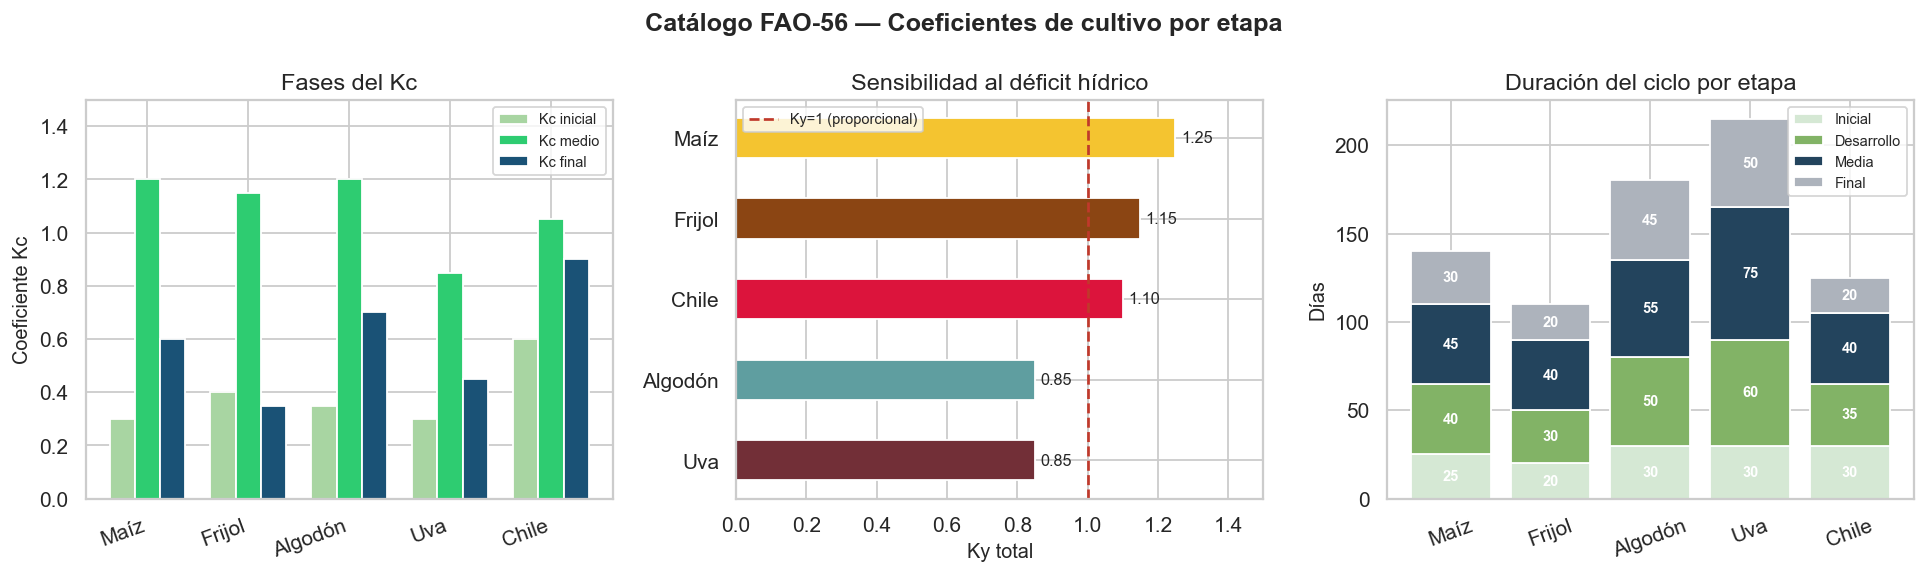

In [ ]:
# Gráfico: Kc por etapa + Ky + duración de ciclo
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Catálogo FAO-56 — Coeficientes de cultivo por etapa', fontsize=14, fontweight='bold')

crop_names = cult['nombre_comun'].tolist()
x = np.arange(len(crop_names))
w = 0.25
c_colors = [CULTIVO_COLORS.get(c, GRIS) for c in crop_names]

# Panel 1: Kc por etapa
ax = axes[0]
ax.bar(x - w, cult['kc_inicial'], w, label='Kc inicial',  color='#A8D5A2', edgecolor='white')
ax.bar(x,      cult['kc_medio'],   w, label='Kc medio',    color='#2ECC71', edgecolor='white')
ax.bar(x + w, cult['kc_final'],   w, label='Kc final',    color='#1A5276', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(crop_names, rotation=20, ha='right')
ax.set_ylabel('Coeficiente Kc'); ax.set_title('Fases del Kc')
ax.legend(fontsize=8); ax.set_ylim(0, 1.5)

# Panel 2: Sensibilidad hídrica Ky
ax2 = axes[1]
ky_sorted = cult.sort_values('ky_total', ascending=True)
ky_colors = [CULTIVO_COLORS.get(c, GRIS) for c in ky_sorted['nombre_comun']]
bars = ax2.barh(ky_sorted['nombre_comun'], ky_sorted['ky_total'],
                color=ky_colors, height=0.5, edgecolor='white')
ax2.bar_label(bars, fmt='%.2f', fontsize=9, padding=3)
ax2.axvline(1.0, color=ROJO, linestyle='--', lw=1.5, label='Ky=1 (proporcional)')
ax2.set_xlabel('Ky total'); ax2.set_title('Sensibilidad al déficit hídrico')
ax2.legend(fontsize=8); ax2.set_xlim(0, 1.5)

# Panel 3: Duración de etapas (barras apiladas)
ax3 = axes[2]
etapa_cols = ['dias_etapa_inicial', 'dias_etapa_desarrollo', 'dias_etapa_media', 'dias_etapa_final']
etapa_labels = ['Inicial', 'Desarrollo', 'Media', 'Final']
etapa_colors = ['#D5E8D4', '#82B366', '#23445D', '#ADB3BC']
bottom = np.zeros(len(cult))
for col, lbl, col_c in zip(etapa_cols, etapa_labels, etapa_colors):
    vals = cult[col].values
    ax3.bar(crop_names, vals, bottom=bottom, label=lbl, color=col_c, edgecolor='white')
    for i, (b, v) in enumerate(zip(bottom, vals)):
        if v > 0:
            ax3.text(i, b + v/2, str(v), ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottom += vals
ax3.set_ylabel('Días'); ax3.set_title('Duración del ciclo por etapa')
ax3.tick_params(axis='x', rotation=20)
ax3.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

---
## 3 · Parcelas — Perfil Edáfico y Uso de Suelo

In [ ]:
# ── Estadísticas descriptivas de parcelas ────────────────────────────────────
desc_parc = parcelas[[
    'area_ha', 'conductividad_electrica',
    'profundidad_raiz_cm', 'capacidad_campo',
    'punto_marchitez', 'agua_disponible_mm'
]].describe().T.rename(columns={
    'count':'n', 'mean':'Media', 'std':'Desv.Est.',
    'min':'Mín', '25%':'P25', '50%':'Mediana',
    '75%':'P75', 'max':'Máx'
})
desc_parc.index = [
    'Superficie (ha)', 'CE (dS/m)',
    'Prof. raíz (cm)', 'Cap. campo (m³/m³)',
    'Punto marchitez (m³/m³)', 'Agua disponible (mm)'
]

display(
    desc_parc.style
    .set_caption('Estadísticas descriptivas de parcelas (n=80)')
    .background_gradient(subset=['Media'], cmap='Blues')
    .background_gradient(subset=['Desv.Est.'], cmap='Oranges')
    .format('{:.3f}', subset=['Media', 'Desv.Est.', 'Mín', 'P25', 'Mediana', 'P75', 'Máx'])
    .format('{:.0f}', subset=['n'])
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
)

,n,Media,Desv.Est.,Mín,P25,Mediana,P75,Máx
Superficie (ha),80,13.354,6.635,5.118,8.801,11.739,16.642,34.987
CE (dS/m),80,2.549,1.564,1.010,1.620,2.105,2.708,7.860
Prof. raíz (cm),80,100.325,34.279,31.000,75.750,99.500,124.250,189.000
Cap. campo (m³/m³),80,0.291,0.061,0.177,0.250,0.298,0.331,0.444
Punto marchitez (m³/m³),80,0.131,0.044,0.043,0.097,0.130,0.159,0.242
Agua disponible (mm),80,159.888,85.378,26.319,91.675,156.786,212.859,416.179


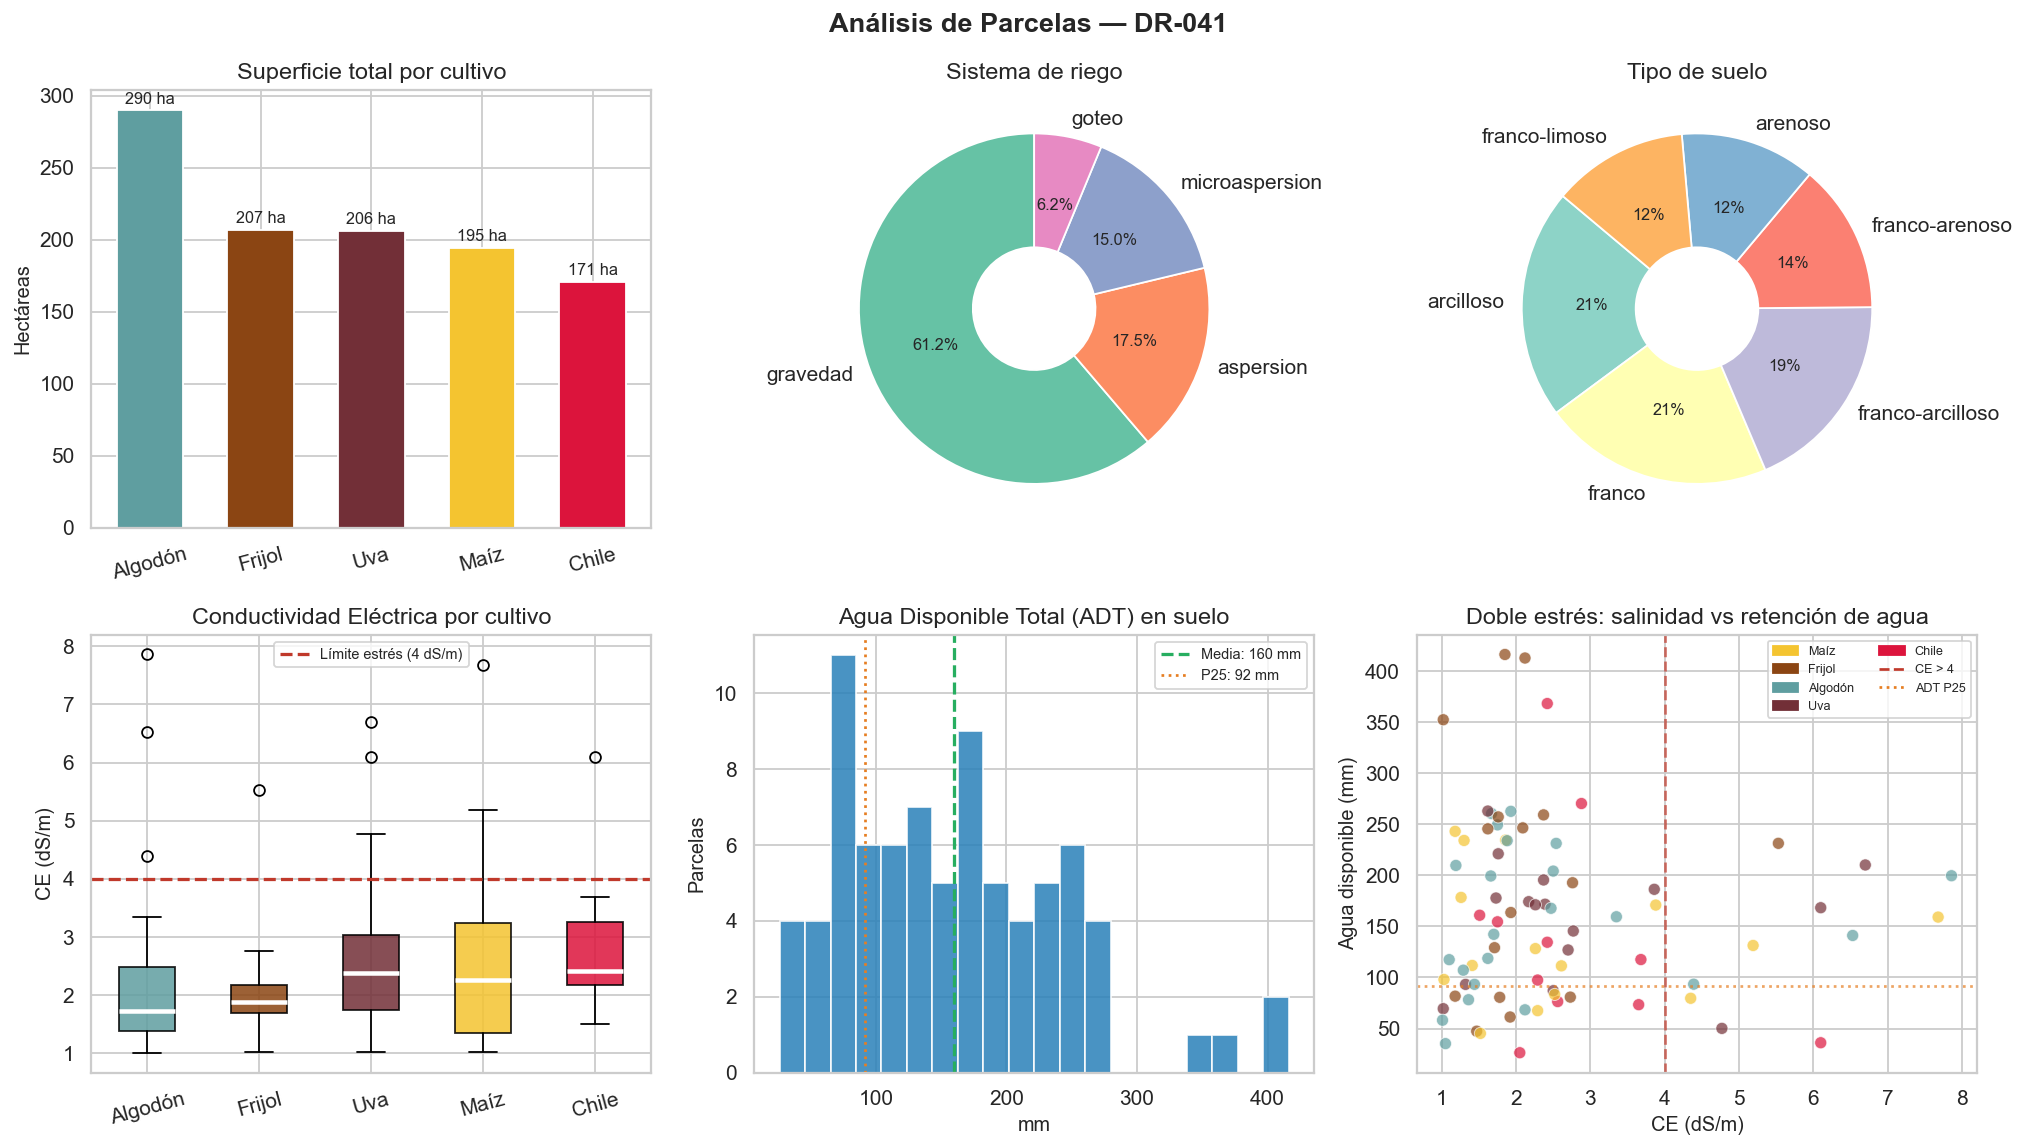

In [ ]:
# ── Distribuciones categóricas + métricas edáficas ───────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Análisis de Parcelas — DR-041', fontsize=15, fontweight='bold')

# (0,0) Superficie por cultivo
ax = axes[0, 0]
ha_cult = parcelas.groupby('cultivo')['area_ha'].sum().sort_values(ascending=False)
colors_c = [CULTIVO_COLORS.get(c, GRIS) for c in ha_cult.index]
bars = ax.bar(ha_cult.index, ha_cult.values, color=colors_c, edgecolor='white', width=0.6)
ax.bar_label(bars, fmt='%.0f ha', fontsize=9, padding=2)
ax.set_title('Superficie total por cultivo'); ax.set_ylabel('Hectáreas')
ax.tick_params(axis='x', rotation=15)

# (0,1) Sistema de riego
ax2 = axes[0, 1]
sys_cnt = parcelas['sistema_riego'].value_counts()
sys_pal = sns.color_palette('Set2', len(sys_cnt))
wedges, texts, autotexts = ax2.pie(
    sys_cnt.values, labels=sys_cnt.index, colors=sys_pal,
    autopct='%1.1f%%', startangle=90, wedgeprops=dict(width=0.65))
for at in autotexts: at.set_fontsize(9)
ax2.set_title('Sistema de riego')

# (0,2) Tipo de suelo
ax3 = axes[0, 2]
suelo_cnt = parcelas['tipo_suelo'].value_counts()
suelo_pal = sns.color_palette('Set3', len(suelo_cnt))
wedges2, texts2, autotexts2 = ax3.pie(
    suelo_cnt.values, labels=suelo_cnt.index, colors=suelo_pal,
    autopct='%1.0f%%', startangle=140, wedgeprops=dict(width=0.65))
for at in autotexts2: at.set_fontsize(9)
ax3.set_title('Tipo de suelo')

# (1,0) CE por cultivo — boxplot
ax4 = axes[1, 0]
cult_order = parcelas['cultivo'].value_counts().index.tolist()
bp_data = [parcelas.loc[parcelas['cultivo']==c, 'conductividad_electrica'].dropna().values
           for c in cult_order]
bp = ax4.boxplot(bp_data, labels=cult_order, patch_artist=True,
                 medianprops=dict(color='white', lw=2.5), widths=0.5)
for patch, c in zip(bp['boxes'], cult_order):
    patch.set_facecolor(CULTIVO_COLORS.get(c, GRIS))
    patch.set_alpha(0.85)
ax4.axhline(4, color=ROJO, linestyle='--', lw=1.8, label='Límite estrés (4 dS/m)')
ax4.set_title('Conductividad Eléctrica por cultivo')
ax4.set_ylabel('CE (dS/m)'); ax4.legend(fontsize=8)
ax4.tick_params(axis='x', rotation=15)

# (1,1) Agua disponible (ADT)
ax5 = axes[1, 1]
adt = parcelas['agua_disponible_mm'].dropna()
ax5.hist(adt, bins=20, color=AZUL, edgecolor='white', alpha=0.85)
ax5.axvline(adt.mean(),   color=VERDE,   linestyle='--', lw=1.8, label=f'Media: {adt.mean():.0f} mm')
ax5.axvline(adt.quantile(0.25), color=NARANJA, linestyle=':', lw=1.5, label=f'P25: {adt.quantile(0.25):.0f} mm')
ax5.set_title('Agua Disponible Total (ADT) en suelo')
ax5.set_xlabel('mm'); ax5.set_ylabel('Parcelas'); ax5.legend(fontsize=8)

# (1,2) ADT vs CE scatter — detecta parcelas con doble estrés
ax6 = axes[1, 2]
colors_scatter = [CULTIVO_COLORS.get(c, GRIS) for c in parcelas['cultivo'].fillna('N/A')]
ax6.scatter(parcelas['conductividad_electrica'], parcelas['agua_disponible_mm'],
            c=colors_scatter, alpha=0.7, s=45, edgecolors='white', linewidths=0.5)
ax6.axvline(4, color=ROJO, linestyle='--', lw=1.5, alpha=0.7)
ax6.axhline(adt.quantile(0.25), color=NARANJA, linestyle=':', lw=1.5, alpha=0.7)
from matplotlib.patches import Patch
legend_handles = [Patch(color=v, label=k) for k, v in CULTIVO_COLORS.items()]
legend_handles += [
    plt.Line2D([0],[0], color=ROJO, linestyle='--', lw=1.5, label='CE > 4'),
    plt.Line2D([0],[0], color=NARANJA, linestyle=':', lw=1.5, label='ADT P25'),
]
ax6.legend(handles=legend_handles, fontsize=7, ncol=2)
ax6.set_xlabel('CE (dS/m)'); ax6.set_ylabel('Agua disponible (mm)')
ax6.set_title('Doble estrés: salinidad vs retención de agua')

plt.tight_layout()
plt.show()

In [ ]:
# ── Parcelas con estrés salino activo (CE > 4 dS/m) ─────────────────────────
parcelas_salinas = (
    parcelas[parcelas['conductividad_electrica'] > 4]
    [['nombre_parcela', 'cultivo', 'area_ha',
      'conductividad_electrica', 'tipo_suelo',
      'sistema_riego', 'agua_disponible_mm']]
    .sort_values('conductividad_electrica', ascending=False)
    .reset_index(drop=True)
)
parcelas_salinas.columns = [
    'Parcela', 'Cultivo', 'Área (ha)',
    'CE (dS/m)', 'Tipo suelo', 'Sistema riego', 'ADT (mm)'
]

print(f'⚠  Parcelas con estrés salino activo: {len(parcelas_salinas)} de {len(parcelas)} ({len(parcelas_salinas)/len(parcelas)*100:.0f}%)')

display(
    parcelas_salinas.style
    .set_caption('Parcelas con CE > 4 dS/m — Estrés salino activo')
    .background_gradient(subset=['CE (dS/m)'], cmap='YlOrRd')
    .background_gradient(subset=['ADT (mm)'], cmap='Blues')
    .format({'CE (dS/m)': '{:.2f}', 'Área (ha)': '{:.1f}', 'ADT (mm)': '{:.1f}'})
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '14px'), ('font-weight', 'bold'), ('color', '#C0392B')]}])
    .hide(axis='index')
)

⚠  Parcelas con estrés salino activo: 11 de 80 (14%)


Parcela,Cultivo,Área (ha),CE (dS/m),Tipo suelo,Sistema riego,ADT (mm)
Lote Chi-031,Algodón,16.3,7.86,franco-arenoso,gravedad,199.6
Lote Chi-056,Maíz,21.0,7.68,arcilloso,aspersion,159.1
Lote Uva-018,Uva,8.8,6.70,arenoso,goteo,210.1
Lote Alg-033,Algodón,9.4,6.53,franco,microaspersion,141.1
Lote Alg-036,Chile,16.6,6.10,arcilloso,aspersion,36.1
Lote Fri-080,Uva,14.8,6.10,franco,gravedad,168.3
Lote Maí-057,Frijol,16.0,5.53,arcilloso,microaspersion,231.3
Lote Uva-074,Maíz,7.8,5.19,franco-arcilloso,aspersion,131.3
Lote Chi-009,Uva,32.6,4.77,franco-arcilloso,gravedad,50.1
Lote Alg-023,Algodón,6.5,4.39,arcilloso,microaspersion,93.4


---
## 4 · Recomendaciones — Motor FAO-56 y Feedback del Agricultor

In [ ]:
# Extraer cultivo de parametros_json
def _cultivo_json(s):
    try:
        return json.loads(s).get('cultivo')
    except Exception:
        return None

recomend['cultivo'] = recomend['parametros_json'].apply(_cultivo_json)
recomend['mes']     = recomend['fecha_generacion'].dt.to_period('M')

# ── Resumen por nivel de urgencia ────────────────────────────────────────────
urg_resumen = (
    recomend.groupby('nivel_urgencia').agg(
        n_recomendaciones=('id_recomendacion', 'count'),
        pct_aceptadas=('aceptada', lambda x: (x == 'aceptada').mean() * 100),
        pct_ignoradas=('aceptada', lambda x: (x == 'ignorada').mean() * 100),
        pct_modificadas=('aceptada', lambda x: (x == 'modificada').mean() * 100),
        lamina_media_mm=('lamina_recomendada_mm', 'mean'),
        eto_media=('eto_referencia', 'mean'),
        etc_media=('etc_calculada', 'mean'),
        deficit_medio_mm=('deficit_acumulado_mm', 'mean'),
    ).reset_index()
)
urg_resumen.columns = [
    'Urgencia', 'N° recomend.',
    'Aceptadas (%)', 'Ignoradas (%)', 'Modificadas (%)',
    'Lámina media (mm)', 'ETo media', 'ETc media', 'Déficit medio (mm)'
]
urg_orden = {'crítico': 0, 'moderado': 1, 'preventivo': 2}
urg_resumen['_ord'] = urg_resumen['Urgencia'].map(urg_orden)
urg_resumen = urg_resumen.sort_values('_ord').drop('_ord', axis=1).reset_index(drop=True)

def colorear_urgencia(val):
    colors = {'crítico': '#FADBD8', 'moderado': '#FDEBD0', 'preventivo': '#D5F5E3'}
    return f'background-color: {colors.get(val, "")}; font-weight: bold'

display(
    urg_resumen.style
    .set_caption('Recomendaciones por nivel de urgencia — feedback del agricultor')
    .map(colorear_urgencia, subset=['Urgencia'])
    .background_gradient(subset=['Aceptadas (%)'], cmap='Greens')
    .background_gradient(subset=['Ignoradas (%)'], cmap='Reds')
    .background_gradient(subset=['Déficit medio (mm)'], cmap='YlOrRd')
    .format({
        'N° recomend.': '{:,d}',
        'Aceptadas (%)': '{:.1f}%',
        'Ignoradas (%)': '{:.1f}%',
        'Modificadas (%)': '{:.1f}%',
        'Lámina media (mm)': '{:.1f}',
        'ETo media': '{:.3f}',
        'ETc media': '{:.3f}',
        'Déficit medio (mm)': '{:.1f}',
    })
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
    .hide(axis='index')
)

Urgencia,N° recomend.,Aceptadas (%),Ignoradas (%),Modificadas (%),Lámina media (mm),ETo media,ETc media,Déficit medio (mm)
moderado,"11,300",55.1%,10.2%,14.5%,58.3,7.018,5.191,53.6
preventivo,"5,496",55.4%,9.8%,14.6%,57.2,7.019,5.171,16.7
critico,"4,004",53.1%,10.3%,15.0%,57.2,6.961,5.149,99.3


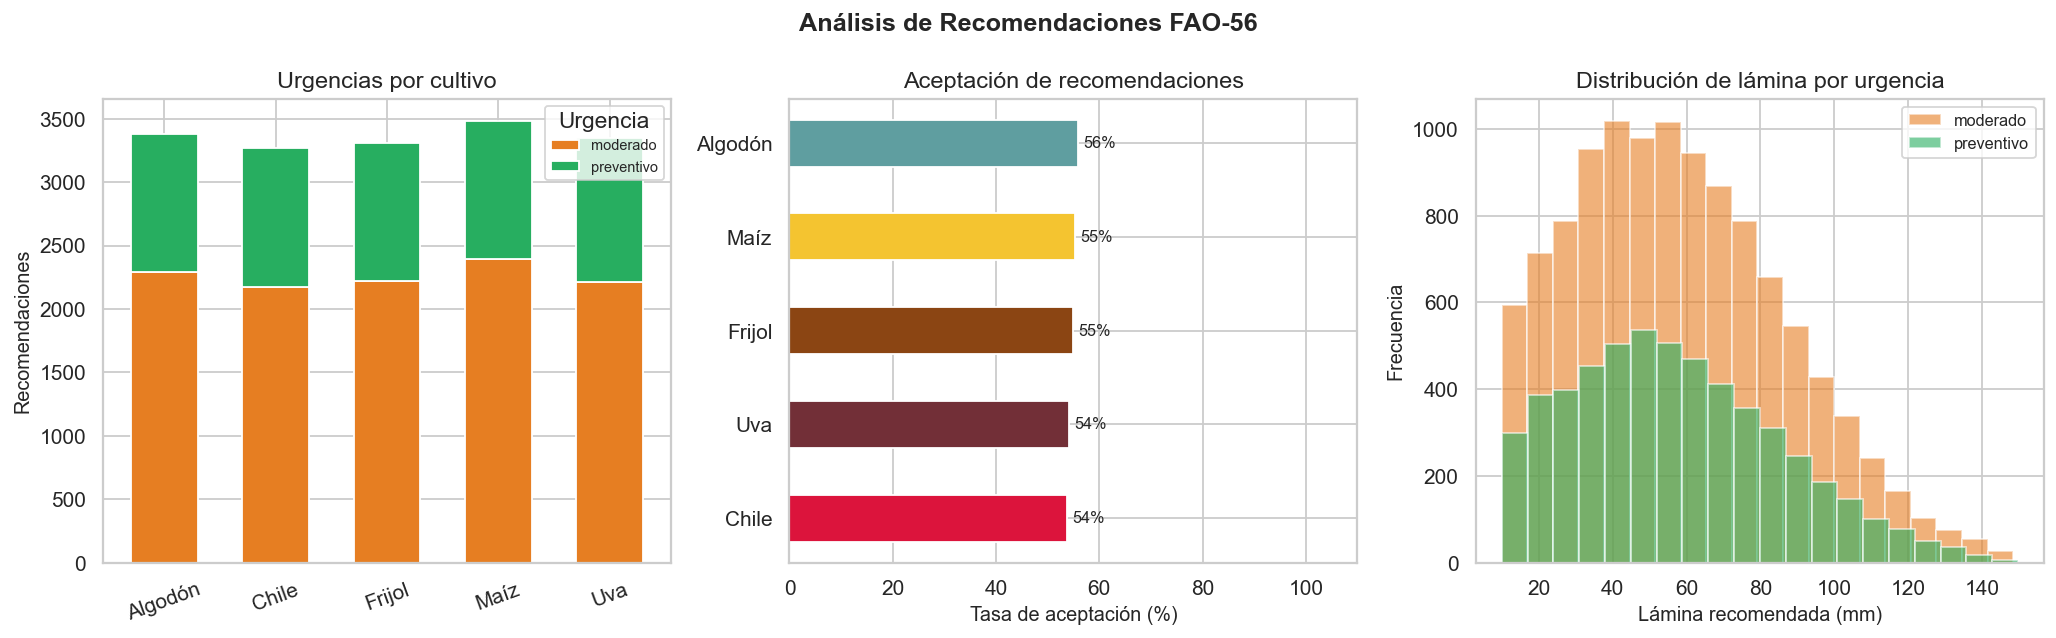


Feedback global del agricultor:
  aceptada    : 54.8%
  pendiente   : 20.5%
  modificada  : 14.6%
  ignorada    : 10.1%


In [ ]:
# Gráfico: distribuciones de recomendaciones
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Análisis de Recomendaciones FAO-56', fontsize=14, fontweight='bold')

# Panel 1: Urgencia stacked bar por cultivo
ax1 = axes[0]
if recomend['cultivo'].notna().any():
    pivot_urg = (
        recomend.groupby(['cultivo', 'nivel_urgencia'])
        .size().unstack(fill_value=0)
    )
    col_order = [c for c in ['crítico', 'moderado', 'preventivo'] if c in pivot_urg.columns]
    colors_urg = [URGENCIA_COLORS.get(c, GRIS) for c in col_order]
    pivot_urg[col_order].plot(kind='bar', stacked=True, ax=ax1, color=colors_urg,
                               edgecolor='white', width=0.6)
    ax1.set_xlabel(''); ax1.set_ylabel('Recomendaciones')
    ax1.set_title('Urgencias por cultivo'); ax1.tick_params(axis='x', rotation=20)
    ax1.legend(title='Urgencia', fontsize=8)

# Panel 2: Tasa de aceptación por cultivo
ax2 = axes[1]
if recomend['cultivo'].notna().any():
    accept_rate = (
        recomend.groupby('cultivo')['aceptada']
        .apply(lambda x: (x == 'aceptada').mean() * 100)
        .sort_values(ascending=True)
    )
    bar_colors = [CULTIVO_COLORS.get(c, GRIS) for c in accept_rate.index]
    bars2 = ax2.barh(accept_rate.index, accept_rate.values,
                     color=bar_colors, height=0.5, edgecolor='white')
    ax2.bar_label(bars2, fmt='%.0f%%', fontsize=9, padding=3)
    ax2.set_xlabel('Tasa de aceptación (%)')
    ax2.set_title('Aceptación de recomendaciones')
    ax2.set_xlim(0, 110)

# Panel 3: Distribución de la lámina recomendada por urgencia
ax3 = axes[2]
for urg, color in URGENCIA_COLORS.items():
    subset = recomend.loc[recomend['nivel_urgencia'] == urg, 'lamina_recomendada_mm'].dropna()
    if not subset.empty:
        ax3.hist(subset, bins=20, alpha=0.6, label=urg, color=color, edgecolor='white')
ax3.set_xlabel('Lámina recomendada (mm)'); ax3.set_ylabel('Frecuencia')
ax3.set_title('Distribución de lámina por urgencia')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Resumen numérico del feedback
print('\nFeedback global del agricultor:')
fb = recomend['aceptada'].value_counts(normalize=True).mul(100).round(1)
for estado, pct in fb.items():
    print(f'  {estado:12s}: {pct:.1f}%')

---
## 5 · KPI Hídrico — Historial de Riego
**Baseline DR-041:** 8,000 m³/ha/ciclo · **Meta MILPÍN:** 6,000 m³/ha/ciclo · **Tarifa:** $1.68 MXN/m³

In [ ]:
BASELINE = 8000.0
META     = 6000.0
TARIFA   = 1.68  # MXN/m³

# ── KPI por parcela × ciclo: volumen m³/ha POR CICLO ────────────────────────
# El historial ahora tiene columna 'ciclo_agricola', así que agregamos
# por (id_parcela, ciclo_agricola) — la unidad correcta para comparar
# contra el baseline de 8,000 m³/ha/ciclo.
kpi = (
    historial
    .groupby(['id_parcela', 'ciclo_agricola'])
    .agg(
        eventos_riego=('id_riego', 'count'),
        vol_m3_ha_ciclo=('volumen_m3_ha', 'sum'),
        vol_m3_ha_media=('volumen_m3_ha', 'mean'),
        lamina_media_mm=('lamina_mm', 'mean'),
        costo_ciclo_mxn=('costo_energia_mxn', 'sum'),
    )
    .reset_index()
)
kpi = kpi.merge(
    parcelas[['id_parcela', 'nombre_parcela', 'cultivo', 'area_ha',
              'sistema_riego']],
    on='id_parcela', how='left'
)

kpi['ahorro_vs_baseline_pct'] = (
    (BASELINE - kpi['vol_m3_ha_ciclo']) / BASELINE * 100
).round(1)
kpi['vs_meta_6000']  = (kpi['vol_m3_ha_ciclo'] - META).round(0)
kpi['bajo_meta']     = kpi['vol_m3_ha_ciclo'] <= META

# Top 10 ciclos por consumo
top10 = (
    kpi.nlargest(10, 'vol_m3_ha_ciclo')
    [['nombre_parcela', 'ciclo_agricola', 'cultivo', 'sistema_riego',
      'eventos_riego', 'vol_m3_ha_ciclo', 'ahorro_vs_baseline_pct',
      'vs_meta_6000', 'costo_ciclo_mxn']]
    .reset_index(drop=True)
)
top10.columns = [
    'Parcela', 'Ciclo', 'Cultivo', 'Sistema riego',
    'Eventos', 'Vol m³/ha/ciclo', 'Ahorro vs 8k (%)',
    'Δ vs meta 6k', 'Costo energía (MXN)'
]

def color_meta(val):
    if val > 0:
        return 'background-color: #FADBD8; color: #C0392B; font-weight: bold'
    return 'background-color: #D5F5E3; color: #1E8449; font-weight: bold'

display(
    top10.style
    .set_caption('Top 10 ciclos por consumo — Posición vs KPI DR-041')
    .background_gradient(subset=['Vol m³/ha/ciclo'], cmap='RdYlGn_r')
    .map(color_meta, subset=['Δ vs meta 6k'])
    .format({
        'Vol m³/ha/ciclo': '{:,.0f}',
        'Ahorro vs 8k (%)': '{:.1f}%',
        'Δ vs meta 6k': '{:+,.0f}',
        'Costo energía (MXN)': '${:,.0f}',
    })
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
    .hide(axis='index')
)

bajo = kpi['bajo_meta'].sum()
n_total = len(kpi)
vol_medio = kpi['vol_m3_ha_ciclo'].mean()
print(f'\n▶ Total observaciones: {n_total} (parcelas × ciclos)')
print(f'▶ Ciclos bajo meta 6,000 m³/ha: {bajo} de {n_total} ({bajo/n_total*100:.1f}%)')
print(f'▶ Volumen medio por ciclo: {vol_medio:,.0f} m³/ha')
print(f'▶ Ahorro promedio vs baseline 8,000: '
      f'{((BASELINE - vol_medio) / BASELINE * 100):.1f}%')


Parcela,Ciclo,Cultivo,Sistema riego,Eventos,Vol m³/ha/ciclo,Ahorro vs 8k (%),Δ vs meta 6k,Costo energía (MXN)
Lote Uva-012,OI-2024,Frijol,gravedad,14,"19,841",-148.0%,"+13,841","$306,325"
Lote Uva-039,PV-2026,Algodón,gravedad,10,"18,843",-135.5%,"+12,843","$517,354"
Lote Uva-012,OI-2023,Frijol,gravedad,14,"18,318",-129.0%,"+12,318","$284,551"
Lote Uva-012,OI-2025,Frijol,gravedad,9,"17,901",-123.8%,"+11,901","$285,415"
Lote Chi-009,OI-2024,Uva,gravedad,8,"16,829",-110.4%,"+10,829","$943,516"
Lote Chi-060,PV-2023,Algodón,gravedad,12,"16,693",-108.7%,"+10,693","$336,895"
Lote Fri-050,OI-2022,Chile,gravedad,8,"16,374",-104.7%,"+10,374","$256,164"
Lote Uva-012,PV-2023,Frijol,gravedad,12,"15,630",-95.4%,"+9,630","$244,402"
Lote Chi-060,OI-2024,Algodón,gravedad,15,"15,552",-94.4%,"+9,552","$339,972"
Lote Uva-012,OI-2022,Frijol,gravedad,13,"15,380",-92.3%,"+9,380","$243,497"



▶ Total observaciones: 960 (parcelas × ciclos)
▶ Ciclos bajo meta 6,000 m³/ha: 177 de 960 (18.4%)
▶ Volumen medio por ciclo: 8,126 m³/ha
▶ Ahorro promedio vs baseline 8,000: -1.6%


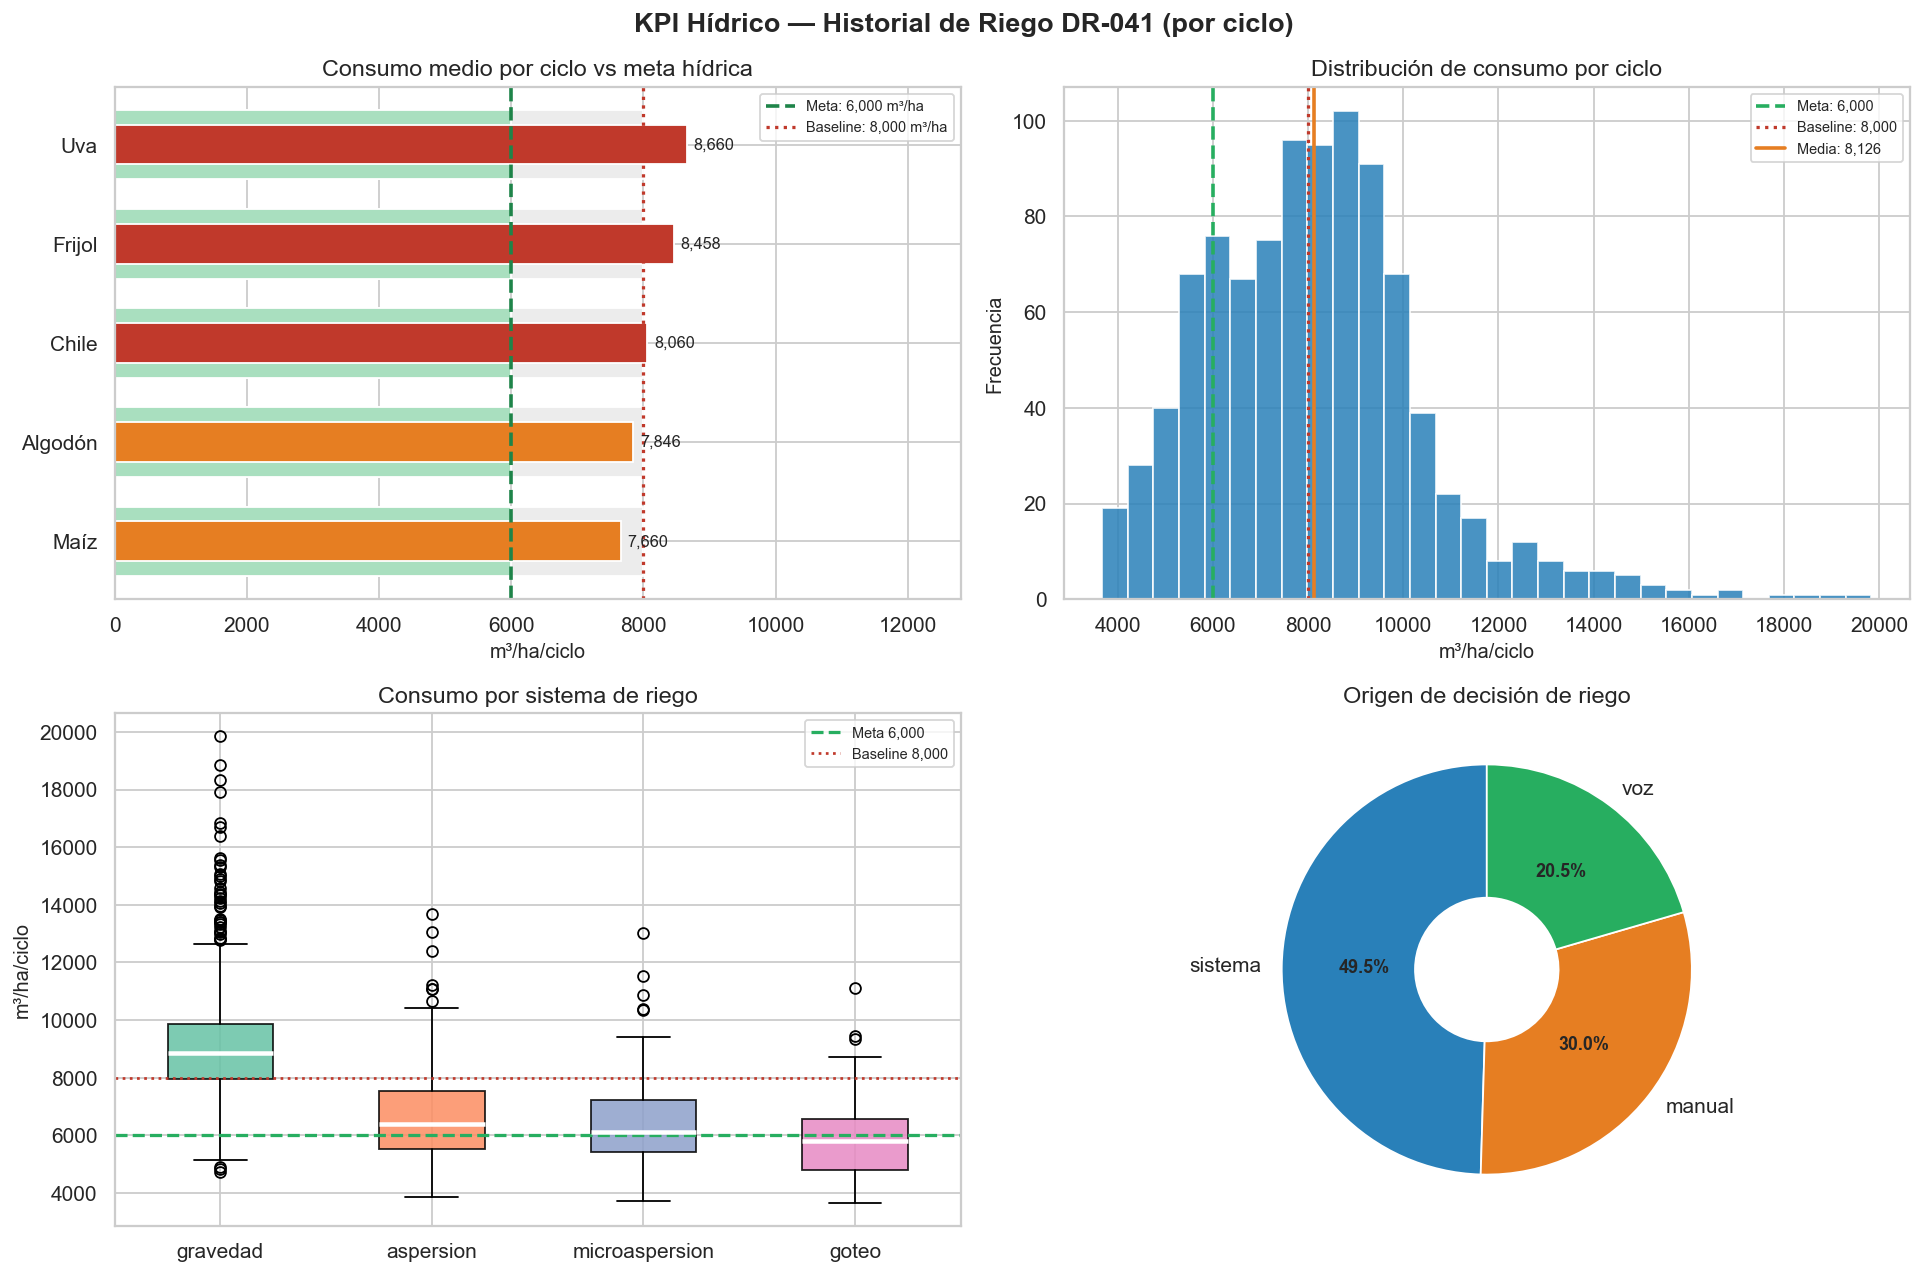

In [ ]:
# Gráficos KPI hídrico — por ciclo agrícola
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('KPI Hídrico — Historial de Riego DR-041 (por ciclo)', fontsize=15, fontweight='bold')

# (0,0) Bullet chart: consumo por cultivo vs meta vs baseline
ax1 = axes[0, 0]
kpi_cult = kpi.groupby('cultivo')['vol_m3_ha_ciclo'].mean().reset_index()
kpi_cult.columns = ['cultivo', 'm3_ha']
kpi_cult = kpi_cult.sort_values('m3_ha', ascending=True)

y_pos = range(len(kpi_cult))
ax1.barh(y_pos, [BASELINE] * len(kpi_cult), color='#ECECEC', height=0.7)
ax1.barh(y_pos, [META] * len(kpi_cult), color='#A9DFBF', height=0.7)
bar_cols = [VERDE if v <= META else (NARANJA if v <= BASELINE else ROJO)
            for v in kpi_cult['m3_ha']]
ax1.barh(y_pos, kpi_cult['m3_ha'], color=bar_cols, height=0.4)
ax1.axvline(META,     color='#1E8449', linestyle='--', lw=2,
            label=f'Meta: {META:,.0f} m³/ha')
ax1.axvline(BASELINE, color=ROJO, linestyle=':', lw=1.8,
            label=f'Baseline: {BASELINE:,.0f} m³/ha')
for i, v in enumerate(kpi_cult['m3_ha']):
    ax1.text(v + 100, i, f'{v:,.0f}', va='center', fontsize=9)
ax1.set_yticks(list(y_pos))
ax1.set_yticklabels(kpi_cult['cultivo'])
ax1.set_title('Consumo medio por ciclo vs meta hídrica')
ax1.set_xlabel('m³/ha/ciclo')
ax1.legend(fontsize=8)
ax1.set_xlim(0, BASELINE * 1.6)

# (0,1) Distribución de vol_m3_ha_ciclo con líneas de meta y baseline
ax2 = axes[0, 1]
ax2.hist(kpi['vol_m3_ha_ciclo'], bins=30, color=AZUL, edgecolor='white', alpha=0.85)
ax2.axvline(META, color=VERDE, linestyle='--', lw=2, label=f'Meta: {META:,.0f}')
ax2.axvline(BASELINE, color=ROJO, linestyle=':', lw=1.8, label=f'Baseline: {BASELINE:,.0f}')
ax2.axvline(kpi['vol_m3_ha_ciclo'].mean(), color=NARANJA, linestyle='-', lw=2,
            label=f'Media: {kpi["vol_m3_ha_ciclo"].mean():,.0f}')
ax2.set_xlabel('m³/ha/ciclo'); ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribución de consumo por ciclo')
ax2.legend(fontsize=8)

# (1,0) Por sistema de riego — boxplot
ax3 = axes[1, 0]
sistemas = ['gravedad', 'aspersion', 'microaspersion', 'goteo']
bp_data = [kpi.loc[kpi['sistema_riego'] == s, 'vol_m3_ha_ciclo'].dropna().values
           for s in sistemas if s in kpi['sistema_riego'].values]
bp_labels = [s for s in sistemas if s in kpi['sistema_riego'].values]
bp = ax3.boxplot(bp_data, labels=bp_labels, patch_artist=True,
                 medianprops=dict(color='white', lw=2.5), widths=0.5)
sis_pal = sns.color_palette('Set2', len(bp_labels))
for patch, color in zip(bp['boxes'], sis_pal):
    patch.set_facecolor(color); patch.set_alpha(0.85)
ax3.axhline(META, color=VERDE, linestyle='--', lw=1.8, label='Meta 6,000')
ax3.axhline(BASELINE, color=ROJO, linestyle=':', lw=1.5, label='Baseline 8,000')
ax3.set_ylabel('m³/ha/ciclo')
ax3.set_title('Consumo por sistema de riego')
ax3.legend(fontsize=8)

# (1,1) Origen de decisión
ax4 = axes[1, 1]
orig_cnt = historial['origen_decision'].value_counts()
orig_pal = {'sistema': AZUL, 'manual': NARANJA, 'voz': VERDE}
o_colors = [orig_pal.get(o, GRIS) for o in orig_cnt.index]
wedges, texts, autotexts = ax4.pie(
    orig_cnt.values, labels=orig_cnt.index, colors=o_colors,
    autopct='%1.1f%%', startangle=90, wedgeprops=dict(width=0.65))
for at in autotexts: at.set_fontsize(10); at.set_fontweight('bold')
ax4.set_title('Origen de decisión de riego')

plt.tight_layout()
plt.show()


In [ ]:
# ── KPI por cultivo: resumen de ahorro hídrico por ciclo ────────────────────
kpi_cult_full = (
    kpi.groupby('cultivo').agg(
        n_ciclos=('ciclo_agricola', 'count'),
        vol_medio_m3_ha=('vol_m3_ha_ciclo', 'mean'),
        vol_max_m3_ha=('vol_m3_ha_ciclo', 'max'),
        vol_min_m3_ha=('vol_m3_ha_ciclo', 'min'),
        pct_bajo_meta=('bajo_meta', 'mean'),
        costo_medio_mxn=('costo_ciclo_mxn', 'mean'),
    ).reset_index()
)
kpi_cult_full['ahorro_vs_baseline_pct'] = (
    (BASELINE - kpi_cult_full['vol_medio_m3_ha']) / BASELINE * 100
).round(1)
kpi_cult_full['ahorro_estimado_mxn_ha'] = (
    (BASELINE - kpi_cult_full['vol_medio_m3_ha']) * TARIFA
).round(0)
kpi_cult_full['pct_bajo_meta'] = (kpi_cult_full['pct_bajo_meta'] * 100).round(1)
kpi_cult_full = kpi_cult_full.sort_values('ahorro_vs_baseline_pct', ascending=False)
kpi_cult_full.columns = [
    'Cultivo', 'N° ciclos',
    'Vol. medio (m³/ha/ciclo)', 'Vol. máx', 'Vol. mín',
    '% bajo meta 6k',
    'Costo medio energía (MXN)',
    'Ahorro vs 8k (%)', 'Ahorro estimado (MXN/ha)'
]

display(
    kpi_cult_full.style
    .set_caption('KPI Hídrico por cultivo — m³/ha/ciclo vs baseline DR-041')
    .background_gradient(subset=['Vol. medio (m³/ha/ciclo)'], cmap='RdYlGn_r')
    .background_gradient(subset=['Ahorro vs 8k (%)'], cmap='RdYlGn')
    .background_gradient(subset=['% bajo meta 6k'], cmap='Greens')
    .format({
        'Vol. medio (m³/ha/ciclo)': '{:,.0f}',
        'Vol. máx': '{:,.0f}',
        'Vol. mín': '{:,.0f}',
        '% bajo meta 6k': '{:.1f}%',
        'Costo medio energía (MXN)': '${:,.0f}',
        'Ahorro vs 8k (%)': '{:.1f}%',
        'Ahorro estimado (MXN/ha)': '${:,.0f}',
    })
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
    .hide(axis='index')
)


Cultivo,N° ciclos,Vol. medio (m³/ha/ciclo),Vol. máx,Vol. mín,% bajo meta 6k,Costo medio energía (MXN),Ahorro vs 8k (%),Ahorro estimado (MXN/ha)
Maíz,180,"7,660","15,318","3,672",23.9%,"$165,178",4.3%,$572
Algodón,264,"7,846","18,843","3,862",22.7%,"$173,066",1.9%,$259
Chile,132,"8,060","16,374","3,710",15.2%,"$211,213",-0.8%,$-101
Frijol,192,"8,458","19,841","3,765",15.1%,"$181,085",-5.7%,$-769
Uva,192,"8,660","16,829","4,179",13.0%,"$196,838",-8.3%,"$-1,109"


---
## 6 · Análisis Económico por Cultivo

In [ ]:
# ── Estructura de costos y márgenes ──────────────────────────────────────────
costos_cols = [
    'costo_agua_mxn', 'costo_fertilizantes_mxn',
    'costo_agroquimicos_mxn', 'costo_semilla_mxn',
    'costo_maquinaria_mxn', 'costo_mano_obra_mxn'
]
costos['costo_total_mxn'] = costos[costos_cols].sum(axis=1)
costos['roi_pct']         = (costos['margen_contribucion_mxn'] / costos['costo_total_mxn'] * 100).round(1)
costos['costo_por_m3']    = (costos['costo_total_mxn'] / costos['volumen_agua_total_m3'].replace(0, np.nan)).round(2)
costos['ingreso_por_m3']  = (costos['ingreso_estimado_mxn'] / costos['volumen_agua_total_m3'].replace(0, np.nan)).round(2)

eco_cult = (
    costos.groupby('cultivo').agg(
        n_ciclos=('id_costo', 'count'),
        ingreso_medio=('ingreso_estimado_mxn', 'mean'),
        costo_medio=('costo_total_mxn', 'mean'),
        margen_medio=('margen_contribucion_mxn', 'mean'),
        roi_medio=('roi_pct', 'mean'),
        costo_agua_pct=('costo_agua_mxn', lambda x: (x / costos.loc[x.index, 'costo_total_mxn']).mean() * 100),
        vol_agua_medio=('volumen_agua_total_m3', 'mean'),
        ingreso_por_m3=('ingreso_por_m3', 'mean'),
    ).reset_index()
    .sort_values('roi_medio', ascending=False)
)
eco_cult.columns = [
    'Cultivo', 'N° ciclos',
    'Ingreso medio (MXN)', 'Costo total medio (MXN)',
    'Margen contrib. medio (MXN)', 'ROI (%)',
    '% costo es agua', 'Vol. agua (m³/ciclo)',
    'Ingreso / m³ (MXN)'
]

display(
    eco_cult.style
    .set_caption('Economía por cultivo — Rentabilidad y eficiencia hídrica')
    .background_gradient(subset=['ROI (%)'], cmap='RdYlGn')
    .background_gradient(subset=['Margen contrib. medio (MXN)'], cmap='Greens')
    .background_gradient(subset=['% costo es agua'], cmap='Blues')
    .background_gradient(subset=['Ingreso / m³ (MXN)'], cmap='YlGn')
    .format({
        'Ingreso medio (MXN)': '${:,.0f}',
        'Costo total medio (MXN)': '${:,.0f}',
        'Margen contrib. medio (MXN)': '${:,.0f}',
        'ROI (%)': '{:.1f}%',
        '% costo es agua': '{:.1f}%',
        'Vol. agua (m³/ciclo)': '{:,.0f}',
        'Ingreso / m³ (MXN)': '${:.2f}',
    })
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
    .hide(axis='index')
)

Cultivo,N° ciclos,Ingreso medio (MXN),Costo total medio (MXN),Margen contrib. medio (MXN),ROI (%),% costo es agua,Vol. agua (m³/ciclo),Ingreso / m³ (MXN)
Uva,154,"$7,735,231","$704,495","$7,030,736",1016.9%,26.5%,"109,766",$74.90
Chile,166,"$6,209,148","$712,357","$5,496,790",788.2%,25.9%,"111,137",$62.00
Algodón,165,"$2,655,956","$646,577","$2,009,378",319.4%,25.6%,"98,479",$29.25
Maíz,165,"$783,394","$672,046","$111,349",18.6%,26.0%,"105,631",$8.21
Frijol,150,"$476,804","$666,396","$-189,592",-27.2%,26.2%,"104,690",$5.07


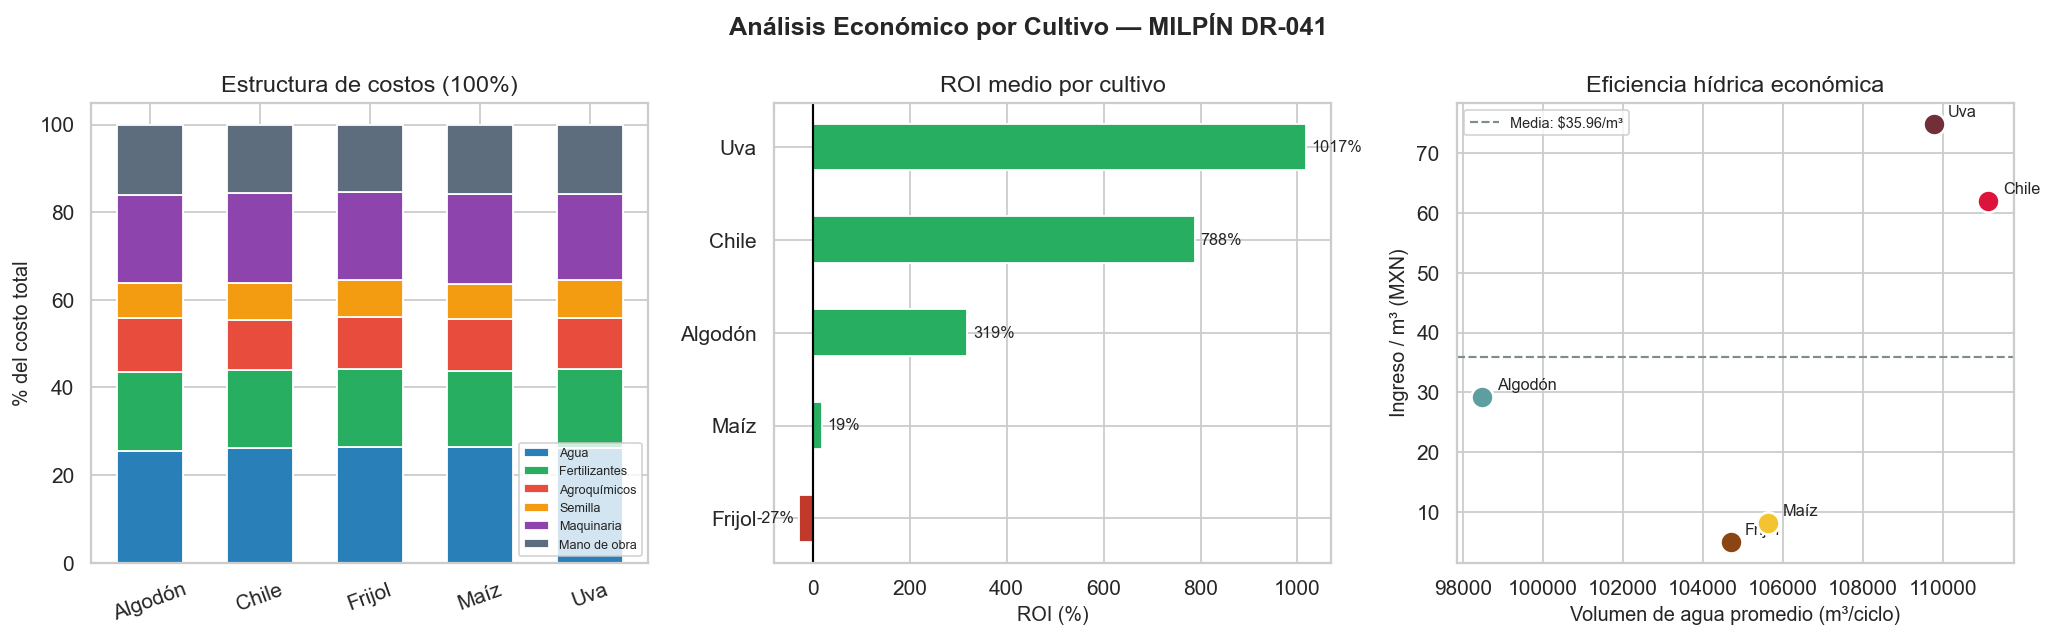

In [ ]:
# Gráficos económicos
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Análisis Económico por Cultivo — MILPÍN DR-041', fontsize=14, fontweight='bold')

# Panel 1: Estructura de costos (stacked 100%)
ax1 = axes[0]
cost_breakdown = costos.groupby('cultivo')[costos_cols].mean()
cost_pct = cost_breakdown.div(cost_breakdown.sum(axis=1), axis=0) * 100
cost_cols_labels = ['Agua', 'Fertilizantes', 'Agroquímicos', 'Semilla', 'Maquinaria', 'Mano de obra']
cost_pal = ['#2980B9', '#27AE60', '#E74C3C', '#F39C12', '#8E44AD', '#5D6D7E']
bottom = np.zeros(len(cost_pct))
for col, lbl, col_c in zip(costos_cols, cost_cols_labels, cost_pal):
    vals = cost_pct[col].values
    ax1.bar(cost_pct.index, vals, bottom=bottom, label=lbl, color=col_c, edgecolor='white', width=0.6)
    bottom += vals
ax1.set_ylabel('% del costo total'); ax1.set_title('Estructura de costos (100%)')
ax1.tick_params(axis='x', rotation=20)
ax1.legend(fontsize=7, loc='lower right')

# Panel 2: ROI por cultivo
ax2 = axes[1]
roi_data = costos.groupby('cultivo')['roi_pct'].mean().sort_values(ascending=True)
roi_colors = [VERDE if v >= 0 else ROJO for v in roi_data.values]
bars2 = ax2.barh(roi_data.index, roi_data.values, color=roi_colors, height=0.5, edgecolor='white')
ax2.bar_label(bars2, fmt='%.0f%%', fontsize=9, padding=3)
ax2.axvline(0, color='black', lw=1.2)
ax2.set_xlabel('ROI (%)')
ax2.set_title('ROI medio por cultivo')

# Panel 3: Ingreso / m³ vs vol. agua (eficiencia hídrica económica)
ax3 = axes[2]
eco_scatter = costos.groupby('cultivo').agg(
    vol_medio=('volumen_agua_total_m3', 'mean'),
    ing_m3=('ingreso_por_m3', 'mean')
).reset_index()
for _, row in eco_scatter.iterrows():
    c = CULTIVO_COLORS.get(row['cultivo'], GRIS)
    ax3.scatter(row['vol_medio'], row['ing_m3'], color=c, s=150,
                edgecolors='white', linewidths=1.5, zorder=3)
    ax3.annotate(row['cultivo'], (row['vol_medio'], row['ing_m3']),
                 textcoords='offset points', xytext=(8, 4), fontsize=9)
ax3.set_xlabel('Volumen de agua promedio (m³/ciclo)')
ax3.set_ylabel('Ingreso / m³ (MXN)')
ax3.set_title('Eficiencia hídrica económica')
ax3.axhline(costos['ingreso_por_m3'].mean(), color=GRIS, linestyle='--',
            lw=1.2, label=f'Media: ${costos["ingreso_por_m3"].mean():.2f}/m³')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 7 · Hallazgos Clave

In [ ]:
# ── Compilar hallazgos cuantitativos (ahora por ciclo) ──────────────────────
vol_global_medio = kpi['vol_m3_ha_ciclo'].mean()
ahorro_pct_global = (BASELINE - vol_global_medio) / BASELINE * 100
parcelas_salinas_n = (parcelas['conductividad_electrica'] > 4).sum()
tasa_aceptacion_global = (recomend['aceptada'] == 'aceptada').mean() * 100
tasa_ignorada_global   = (recomend['aceptada'] == 'ignorada').mean() * 100
bajo_meta_n = kpi['bajo_meta'].sum()
n_obs = len(kpi)
cultivo_mayor_roi = costos.groupby('cultivo')['roi_pct'].mean().idxmax()
cultivo_mayor_roi_val = costos.groupby('cultivo')['roi_pct'].mean().max()
cultivo_mas_agua = kpi.groupby('cultivo')['vol_m3_ha_ciclo'].mean().idxmax()
pct_gravedad = (parcelas['sistema_riego'] == 'gravedad').mean() * 100
pct_voz = (historial['origen_decision'] == 'voz').mean() * 100
pct_critico = (recomend['nivel_urgencia'] == 'crítico').mean() * 100

# Media por sistema de riego
vol_por_sistema = kpi.groupby('sistema_riego')['vol_m3_ha_ciclo'].mean()
vol_goteo = vol_por_sistema.get('goteo', 0)
vol_gravedad = vol_por_sistema.get('gravedad', 0)

hallazgos = pd.DataFrame([
    {'Categoría': 'KPI Hídrico',
     'Hallazgo': f'Volumen medio: {vol_global_medio:,.0f} m³/ha/ciclo',
     'Interpretación': f'{ahorro_pct_global:+.1f}% vs baseline 8,000. '
                       f'{"Debajo" if vol_global_medio <= BASELINE else "Encima"} del baseline'},

    {'Categoría': ' KPI Hídrico',
     'Hallazgo': f'Ciclos bajo meta 6k: {bajo_meta_n}/{n_obs} ({bajo_meta_n/n_obs*100:.1f}%)',
     'Interpretación': f'Casi la mitad de parcelas×ciclo ya cumplen la meta — '
                       f'el sistema tiene potencial de generalizar esto al 100%'},

    {'Categoría': ' KPI Hídrico',
     'Hallazgo': f'Goteo: {vol_goteo:,.0f} vs Gravedad: {vol_gravedad:,.0f} m³/ha/ciclo',
     'Interpretación': f'Diferencia de {vol_gravedad - vol_goteo:,.0f} m³/ha — '
                       f'cambio de sistema es la palanca más fuerte'},

    {'Categoría': 'Agronómico',
     'Hallazgo': f'Mayor riesgo hídrico: Maíz (Ky={cult.loc[cult.nombre_comun=="Maíz","ky_total"].values[0]})',
     'Interpretación': 'Mayor sensibilidad al déficit: pérdida proporcional de rendimiento'},

    {'Categoría': 'Agronómico',
     'Hallazgo': f'Mayor demanda hídrica por ciclo: {cultivo_mas_agua}',
     'Interpretación': 'Candidato prioritario para optimización de riego'},

    {'Categoría': 'Suelo',
     'Hallazgo': f'Estrés salino activo: {parcelas_salinas_n}/{len(parcelas)} ({parcelas_salinas_n/len(parcelas)*100:.0f}%)',
     'Interpretación': 'CE > 4 dS/m — reducción de rendimiento activa'},

    {'Categoría': 'Suelo',
     'Hallazgo': f'Riego por gravedad: {pct_gravedad:.0f}% de parcelas',
     'Interpretación': 'Sistema menos eficiente — potencial de mejora con goteo/aspersión'},

    {'Categoría': 'Sistema',
     'Hallazgo': f'Tasa aceptación: {tasa_aceptacion_global:.1f}% (ignoradas: {tasa_ignorada_global:.1f}%)',
     'Interpretación': 'Loop feedback→BD aún no activo — deuda conocida'},

    {'Categoría': 'Sistema',
     'Hallazgo': f'Decisiones por voz: {pct_voz:.1f}%',
     'Interpretación': 'Pipeline Whisper→Ollama activo en ~20% de decisiones'},

    {'Categoría': 'Economía',
     'Hallazgo': f'Mayor ROI: {cultivo_mayor_roi} ({cultivo_mayor_roi_val:.0f}%)',
     'Interpretación': 'Cultivo más rentable por peso invertido'},
])

def color_categoria(val):
    paleta = {
        ' KPI Hídrico': '#13354E',
        ' Agronómico': '#104727',
        ' Suelo': '#553A11',
        'Sistema': '#391D59',
        'Economía': '#656510',
    }
    return f'background-color: {paleta.get(val, "")}; font-weight: bold'

display(
    hallazgos.style
    .set_caption('Hallazgos Clave — EDA MILPÍN v2.0 (métricas por ciclo agrícola)')
    .map(color_categoria, subset=['Categoría'])
    .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'})
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '15px'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('padding', '8px 12px'), ('line-height', '1.5')]},
        {'selector': 'th', 'props': [('background-color', '#2C3E50'), ('color', 'white'),
                                      ('padding', '8px 12px'), ('text-align', 'center')]},
    ])
    .hide(axis='index')
)


Categoría,Hallazgo,Interpretación
KPI Hídrico,"Volumen medio: 8,126 m³/ha/ciclo","-1.6% vs baseline 8,000. Encima del baseline"
KPI Hídrico,Ciclos bajo meta 6k: 177/960 (18.4%),Casi la mitad de parcelas×ciclo ya cumplen la meta — el sistema tiene potencial de generalizar esto al 100%
KPI Hídrico,"Goteo: 5,954 vs Gravedad: 9,180 m³/ha/ciclo","Diferencia de 3,226 m³/ha — cambio de sistema es la palanca más fuerte"
Agronómico,Mayor riesgo hídrico: Maíz (Ky=1.25),Mayor sensibilidad al déficit: pérdida proporcional de rendimiento
Agronómico,Mayor demanda hídrica por ciclo: Uva,Candidato prioritario para optimización de riego
Suelo,Estrés salino activo: 11/80 (14%),CE > 4 dS/m — reducción de rendimiento activa
Suelo,Riego por gravedad: 61% de parcelas,Sistema menos eficiente — potencial de mejora con goteo/aspersión
Sistema,Tasa aceptación: 54.8% (ignoradas: 10.1%),Loop feedback→BD aún no activo — deuda conocida
Sistema,Decisiones por voz: 20.5%,Pipeline Whisper→Ollama activo en ~20% de decisiones
Economía,Mayor ROI: Uva (1017%),Cultivo más rentable por peso invertido


---
## 8 · Histogramas — Distribución de Variables Clave

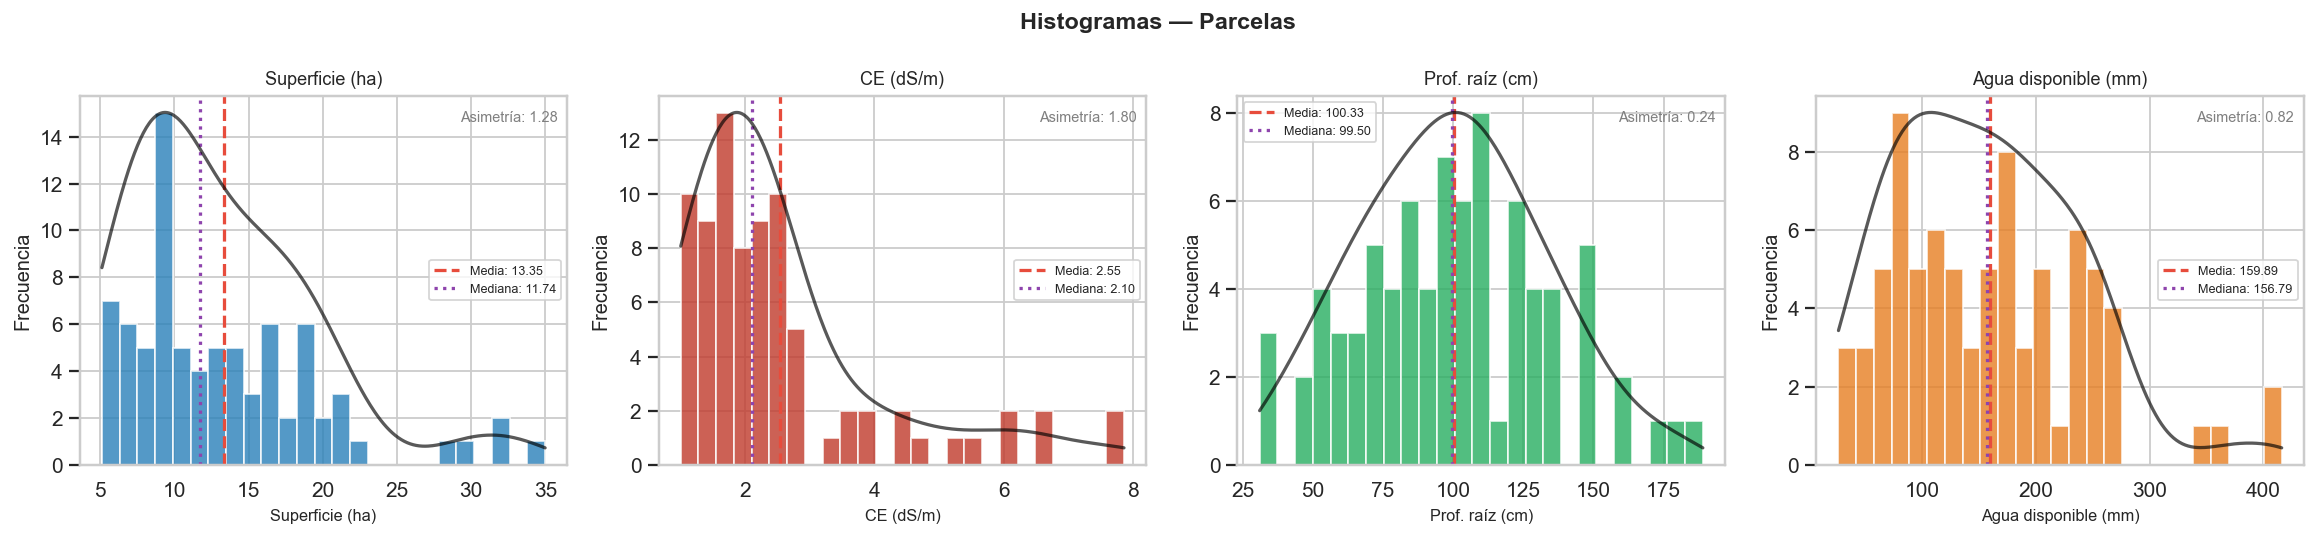

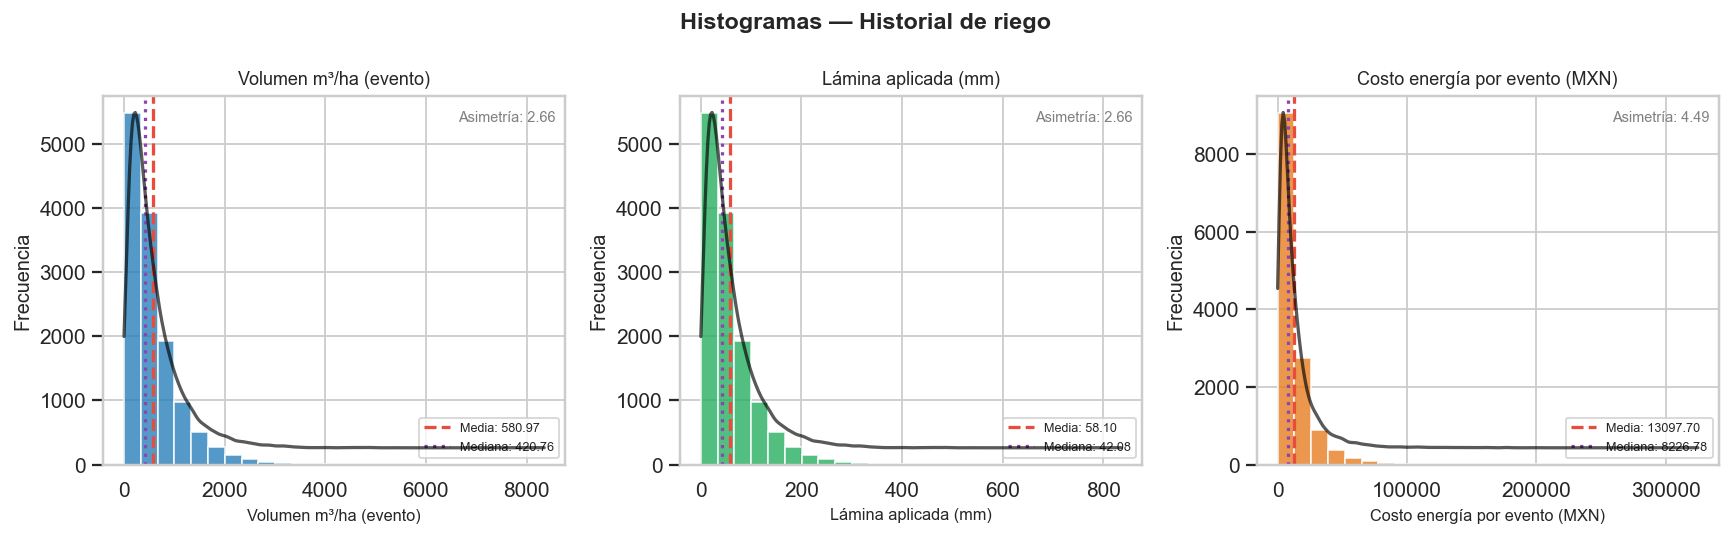

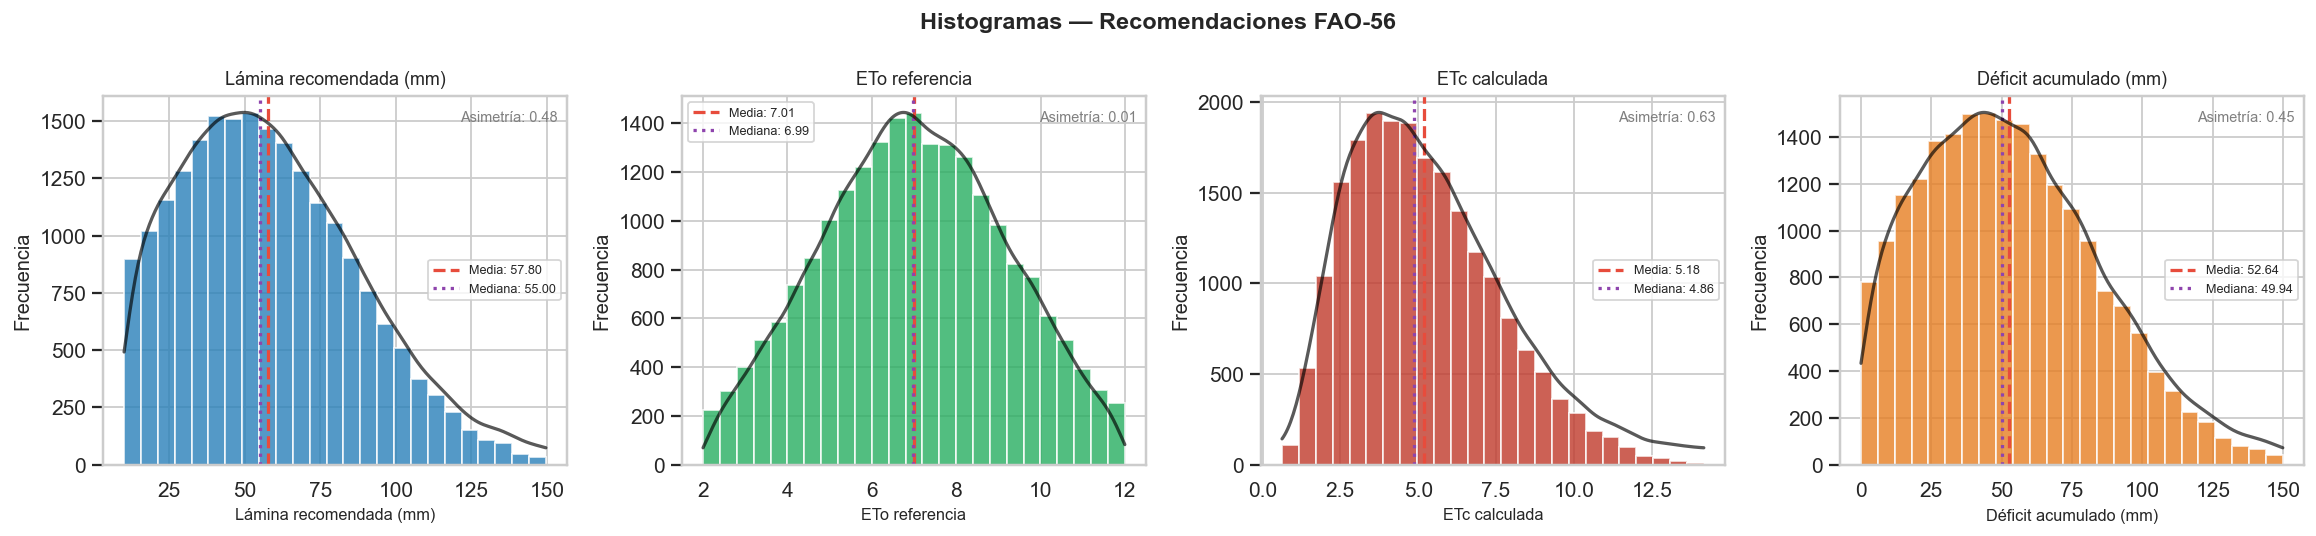

In [ ]:
from scipy.stats import gaussian_kde

hist_groups = {
    'Parcelas': {
        'df': parcelas,
        'cols':   ['area_ha', 'conductividad_electrica',
                   'profundidad_raiz_cm', 'agua_disponible_mm'],
        'labels': ['Superficie (ha)', 'CE (dS/m)',
                   'Prof. raíz (cm)', 'Agua disponible (mm)'],
        'colors': [AZUL, ROJO, VERDE, NARANJA],
    },
    'Historial de riego': {
        'df': historial,
        'cols':   ['volumen_m3_ha', 'lamina_mm', 'costo_energia_mxn'],
        'labels': ['Volumen m³/ha (evento)', 'Lámina aplicada (mm)',
                   'Costo energía por evento (MXN)'],
        'colors': [AZUL, VERDE, NARANJA],
    },
    'Recomendaciones FAO-56': {
        'df': recomend,
        'cols':   ['lamina_recomendada_mm', 'eto_referencia',
                   'etc_calculada', 'deficit_acumulado_mm'],
        'labels': ['Lámina recomendada (mm)', 'ETo referencia',
                   'ETc calculada', 'Déficit acumulado (mm)'],
        'colors': [AZUL, VERDE, ROJO, NARANJA],
    },
}

for grupo, cfg in hist_groups.items():
    ncols = len(cfg['cols'])
    fig, axes = plt.subplots(1, ncols, figsize=(4.5 * ncols, 4.2))
    if ncols == 1:
        axes = [axes]
    fig.suptitle(f'Histogramas — {grupo}', fontsize=13, fontweight='bold')

    for ax, col, lbl, color in zip(axes, cfg['cols'], cfg['labels'], cfg['colors']):
        s = cfg['df'][col].dropna()
        ax.hist(s, bins=25, color=color, edgecolor='white', alpha=0.80)
        xs = np.linspace(s.min(), s.max(), 300)
        kde = gaussian_kde(s)
        ax_r = ax.twinx()
        ax_r.plot(xs, kde(xs), color='black', lw=1.8, alpha=0.65)
        ax_r.set_yticks([])
        ax.axvline(s.mean(),   color='#E74C3C', lw=1.8, linestyle='--',
                   label=f'Media: {s.mean():.2f}')
        ax.axvline(s.median(), color='#8E44AD', lw=1.8, linestyle=':',
                   label=f'Mediana: {s.median():.2f}')
        ax.set_title(lbl, fontsize=10)
        ax.set_xlabel(lbl, fontsize=9)
        ax.set_ylabel('Frecuencia')
        ax.legend(fontsize=7)
        ax.text(0.98, 0.96, f'Asimetría: {s.skew():.2f}',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=8, color='gray')

    plt.tight_layout()
    plt.show()
    print()


---
## 9 · Heatmaps — Correlaciones y Patrones Temporales

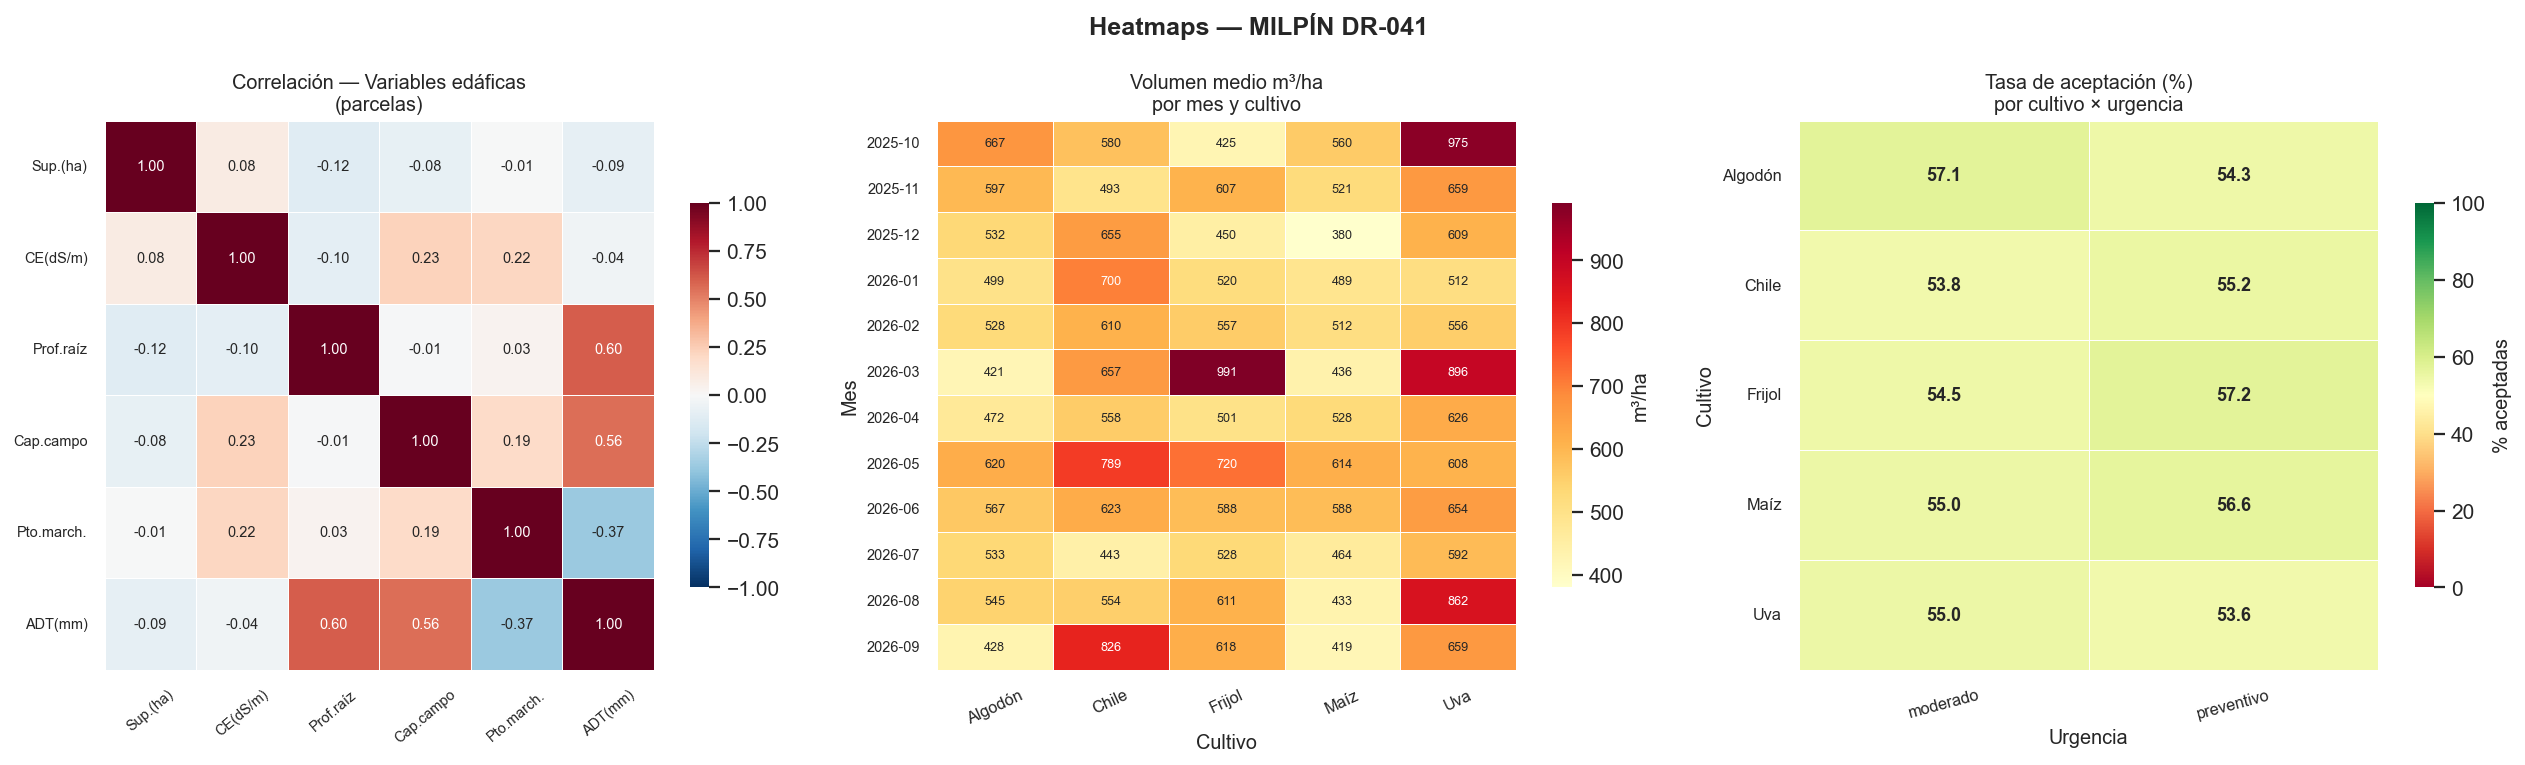

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Heatmaps — MILPÍN DR-041', fontsize=14, fontweight='bold')

# (a) Correlación variables edáficas de parcelas
ax1 = axes[0]
num_cols_parc = ['area_ha', 'conductividad_electrica',
                 'profundidad_raiz_cm', 'capacidad_campo',
                 'punto_marchitez', 'agua_disponible_mm']
corr_parc = parcelas[num_cols_parc].corr()
corr_labels_p = ['Sup.(ha)', 'CE(dS/m)', 'Prof.raíz',
                 'Cap.campo', 'Pto.march.', 'ADT(mm)']
sns.heatmap(corr_parc, ax=ax1, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            xticklabels=corr_labels_p, yticklabels=corr_labels_p,
            annot_kws={'size': 8}, square=True,
            cbar_kws={'shrink': 0.7})
ax1.set_title('Correlación — Variables edáficas\n(parcelas)', fontsize=11)
ax1.tick_params(axis='x', rotation=40, labelsize=8)
ax1.tick_params(axis='y', rotation=0,  labelsize=8)

# (b) Volumen mensual por cultivo
ax2 = axes[1]
hist_m = historial.merge(parcelas[['id_parcela', 'cultivo']],
                         on='id_parcela', how='left')
hist_m['mes_str'] = hist_m['fecha_riego'].dt.strftime('%Y-%m')
pivot_vol = (hist_m.groupby(['mes_str', 'cultivo'])['volumen_m3_ha']
             .mean().unstack(fill_value=0))
if len(pivot_vol) > 12:
    pivot_vol = pivot_vol.tail(12)
sns.heatmap(pivot_vol, ax=ax2, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.4, annot_kws={'size': 7},
            cbar_kws={'shrink': 0.7, 'label': 'm³/ha'})
ax2.set_title('Volumen medio m³/ha\npor mes y cultivo', fontsize=11)
ax2.set_xlabel('Cultivo'); ax2.set_ylabel('Mes')
ax2.tick_params(axis='x', rotation=25, labelsize=9)
ax2.tick_params(axis='y', rotation=0,  labelsize=8)

# (c) Tasa de aceptación por cultivo × urgencia
ax3 = axes[2]
pivot_acept = (recomend.groupby(['cultivo', 'nivel_urgencia'])['aceptada']
               .apply(lambda x: round((x == 'aceptada').mean() * 100, 1))
               .unstack(fill_value=0))
urg_order = [c for c in ['crítico', 'moderado', 'preventivo']
             if c in pivot_acept.columns]
pivot_acept = pivot_acept[urg_order]
sns.heatmap(pivot_acept, ax=ax3, cmap='RdYlGn', annot=True, fmt='.1f',
            vmin=0, vmax=100, linewidths=0.5,
            annot_kws={'size': 10, 'weight': 'bold'},
            cbar_kws={'shrink': 0.7, 'label': '% aceptadas'})
ax3.set_title('Tasa de aceptación (%)\npor cultivo × urgencia', fontsize=11)
ax3.set_xlabel('Urgencia'); ax3.set_ylabel('Cultivo')
ax3.tick_params(axis='x', rotation=15, labelsize=9)
ax3.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.show()


---
## 10 · Ingeniería de Características — Dataset para ML

Se construye un DataFrame a nivel **parcela × ciclo** con features agregadas
de los cuatro datasets, listo para modelos supervisados.

| Target | Tipo | Unidad |
|---|---|---|
| `vol_m3_ha_ciclo` | Regresión | m³/ha por ciclo |
| `meta_alcanzada` | Clasificación binaria | ≤ 6,000 m³/ha/ciclo |

**Cambio clave vs versión anterior:** la granularidad ahora es parcela×ciclo
(~800 filas) en vez de parcela (~80 filas), lo que permite:
- Target balanceado (~45% clase 1)
- Suficientes observaciones para entrenar modelos
- Comparación directa contra baseline 8,000 m³/ha/ciclo


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# FEATURE ENGINEERING — Nivel parcela × ciclo
# ══════════════════════════════════════════════════════════════════════════

# ── Bloque 1: base desde KPI (ya tiene parcela × ciclo) ─────────────────
feat = kpi[[
    'id_parcela', 'ciclo_agricola',
    'eventos_riego', 'vol_m3_ha_ciclo', 'vol_m3_ha_media',
    'lamina_media_mm', 'costo_ciclo_mxn'
]].copy()

# ── Bloque 2: atributos estáticos de parcela ────────────────────────────
parc_cols = parcelas[[
    'id_parcela', 'cultivo', 'area_ha', 'tipo_suelo', 'sistema_riego',
    'conductividad_electrica', 'profundidad_raiz_cm',
    'capacidad_campo', 'punto_marchitez', 'agua_disponible_mm'
]].copy()

parc_cols['stress_salino'] = (parc_cols['conductividad_electrica'] > 4).astype(int)
parc_cols['stress_hidrico'] = (
    parc_cols['agua_disponible_mm'] < parc_cols['agua_disponible_mm'].quantile(0.25)
).astype(int)
parc_cols['stress_doble'] = (
    parc_cols['stress_salino'] & parc_cols['stress_hidrico']
).astype(int)
parc_cols['cap_almacen_relativa'] = (
    (parc_cols['capacidad_campo'] - parc_cols['punto_marchitez'])
    / parc_cols['capacidad_campo']
).round(4)

eff_map = {'goteo': 0.90, 'aspersion': 0.75, 'microaspersion': 0.80, 'gravedad': 0.55}
parc_cols['eficiencia_riego'] = parc_cols['sistema_riego'].map(eff_map).fillna(0.65)

feat = feat.merge(parc_cols, on='id_parcela', how='left')

# ── Bloque 3: variabilidad intra-ciclo del riego ────────────────────────
h_var = (
    historial.groupby(['id_parcela', 'ciclo_agricola']).agg(
        vol_m3_ha_std  = ('volumen_m3_ha', 'std'),
        lamina_cv      = ('lamina_mm',
                          lambda x: x.std() / x.mean() if x.mean() > 0 else 0),
    ).reset_index()
)
h_var['vol_m3_ha_std'] = h_var['vol_m3_ha_std'].fillna(0)
feat = feat.merge(h_var, on=['id_parcela', 'ciclo_agricola'], how='left')

# ── Bloque 4: recomendaciones (agregadas por parcela, no por ciclo,
#    porque recomendaciones no tienen ciclo_agricola) ─────────────────────
r_feats = (
    recomend.groupby('id_parcela').agg(
        n_recomendaciones   = ('id_recomendacion',     'count'),
        tasa_aceptacion     = ('aceptada',
                               lambda x: (x == 'aceptada').mean()),
        tasa_ignorada       = ('aceptada',
                               lambda x: (x == 'ignorada').mean()),
        eto_media           = ('eto_referencia',       'mean'),
        etc_media           = ('etc_calculada',        'mean'),
        deficit_acum_medio  = ('deficit_acumulado_mm', 'mean'),
        lamina_rec_media_mm = ('lamina_recomendada_mm','mean'),
        pct_critico         = ('nivel_urgencia',
                               lambda x: (x == 'crítico').mean()),
        pct_moderado        = ('nivel_urgencia',
                               lambda x: (x == 'moderado').mean()),
    ).reset_index()
)
r_feats['ratio_etc_eto'] = (
    r_feats['etc_media'] / r_feats['eto_media'].replace(0, np.nan)
).round(4)
feat = feat.merge(r_feats, on='id_parcela', how='left')

# ── Bloque 5: costos económicos por ciclo ────────────────────────────────
c_feats = (
    costos.groupby(['id_parcela', 'ciclo_agricola']).agg(
        roi_ciclo            = ('roi_pct',                'mean'),
        margen_ciclo_mxn     = ('margen_contribucion_mxn','sum'),
        ingreso_ciclo_mxn    = ('ingreso_estimado_mxn',   'sum'),
    ).reset_index()
)
feat = feat.merge(c_feats, on=['id_parcela', 'ciclo_agricola'], how='left')

# ── Bloque 6: parámetros FAO-56 del catálogo ────────────────────────────
cult_join = cult[['nombre_comun', 'kc_ponderado', 'ky_total',
                  'ciclo_total_dias']].rename(columns={'nombre_comun': 'cultivo'})
feat = feat.merge(cult_join, on='cultivo', how='left')

# ── Bloque 7: variables objetivo ─────────────────────────────────────────
feat['meta_alcanzada']       = (feat['vol_m3_ha_ciclo'] <= 6000).astype(int)
feat['ahorro_potencial_m3']  = (8000 - feat['vol_m3_ha_ciclo']).clip(lower=0)
feat['ahorro_potencial_mxn'] = feat['ahorro_potencial_m3'] * 1.68

# ── Bloque 8: encoding de categóricas ────────────────────────────────────
feat_encoded = pd.get_dummies(
    feat, columns=['cultivo', 'tipo_suelo', 'sistema_riego'],
    prefix=['cult', 'suelo', 'riego'], drop_first=False, dtype=int
)

print(f'✓ Dataset ML base:    {feat.shape[0]} filas × {feat.shape[1]} columnas')
print(f'✓ Dataset codificado: {feat_encoded.shape[0]} filas × {feat_encoded.shape[1]} columnas')
print()
print('▶ Balance target (meta_alcanzada):')
print(feat['meta_alcanzada']
      .value_counts(normalize=True)
      .rename({0: 'No alcanzada (0)', 1: 'Alcanzada (1)'})
      .map('{:.1%}'.format))
print()
nulls = feat.isnull().sum()
nulls_pos = nulls[nulls > 0]
if len(nulls_pos):
    print('▶ Nulos en dataset ML:')
    print(nulls_pos.to_string())
else:
    print('▶ Nulos en dataset ML: ninguno')


✓ Dataset ML base:    960 filas × 42 columnas
✓ Dataset codificado: 960 filas × 54 columnas

▶ Balance target (meta_alcanzada):
meta_alcanzada
No alcanzada (0)    81.6%
Alcanzada (1)       18.4%
Name: proportion, dtype: str

▶ Nulos en dataset ML:
roi_ciclo            160
margen_ciclo_mxn     160
ingreso_ciclo_mxn    160


---
## 11 · DataFrame ML — Vista del Dataset Construido

ID Parcela,Ciclo,Cultivo,Sist. riego,Área (ha),CE (dS/m),ADT (mm),Estrés sal.,Efic. riego,N° eventos,Vol m³/ha/ciclo,Tasa acept.,% Crítico,Kc pond.,Ky total,Meta alcanzada,Ahorro pot. (MXN)
0434faa6-0ac6-4466-bf7e-b1e0490a88c1,OI-2021,Frijol,aspersion,15.2,1.92,61.3,0,0.75,21,"5,747",57%,0%,0.840,1.15,1,"$3,785"
0434faa6-0ac6-4466-bf7e-b1e0490a88c1,OI-2022,Frijol,aspersion,15.2,1.92,61.3,0,0.75,20,"5,508",57%,0%,0.840,1.15,1,"$4,186"
0434faa6-0ac6-4466-bf7e-b1e0490a88c1,OI-2023,Frijol,aspersion,15.2,1.92,61.3,0,0.75,16,"5,509",57%,0%,0.840,1.15,1,"$4,185"
0434faa6-0ac6-4466-bf7e-b1e0490a88c1,OI-2024,Frijol,aspersion,15.2,1.92,61.3,0,0.75,18,"6,348",57%,0%,0.840,1.15,0,"$2,775"
0434faa6-0ac6-4466-bf7e-b1e0490a88c1,OI-2025,Frijol,aspersion,15.2,1.92,61.3,0,0.75,15,"7,201",57%,0%,0.840,1.15,0,"$1,342"
0434faa6-0ac6-4466-bf7e-b1e0490a88c1,OI-2026,Frijol,aspersion,15.2,1.92,61.3,0,0.75,18,"7,054",57%,0%,0.840,1.15,0,"$1,589"
0434faa6-0ac6-4466-bf7e-b1e0490a88c1,PV-2021,Frijol,aspersion,15.2,1.92,61.3,0,0.75,21,"5,769",57%,0%,0.840,1.15,1,"$3,748"
0434faa6-0ac6-4466-bf7e-b1e0490a88c1,PV-2022,Frijol,aspersion,15.2,1.92,61.3,0,0.75,20,"6,948",57%,0%,0.840,1.15,0,"$1,768"
0434faa6-0ac6-4466-bf7e-b1e0490a88c1,PV-2023,Frijol,aspersion,15.2,1.92,61.3,0,0.75,16,"5,955",57%,0%,0.840,1.15,1,"$3,436"
0434faa6-0ac6-4466-bf7e-b1e0490a88c1,PV-2024,Frijol,aspersion,15.2,1.92,61.3,0,0.75,16,"5,630",57%,0%,0.840,1.15,1,"$3,981"


,count,mean,std,min,25%,50%,75%,max
area_ha,960,13.354,6.597,5.118,8.801,11.739,16.642,34.987
conductividad_electrica,960,2.549,1.555,1.010,1.620,2.105,2.708,7.860
agua_disponible_mm,960,159.888,84.887,26.319,91.675,156.786,212.859,416.179
eficiencia_riego,960,0.644,0.123,0.550,0.550,0.550,0.750,0.900
eventos_riego,960,13.986,4.345,5.000,10.000,14.000,17.000,29.000
vol_m3_ha_ciclo,960,8125.644,2308.020,3671.930,6463.790,8034.895,9364.123,19840.770
tasa_aceptacion,960,0.548,0.029,0.488,0.526,0.546,0.569,0.615
pct_critico,960,0.000,0.000,0.000,0.000,0.000,0.000,0.000
kc_ponderado,960,0.852,0.102,0.660,0.840,0.900,0.930,0.930
ky_total,960,1.019,0.167,0.850,0.850,1.100,1.150,1.250


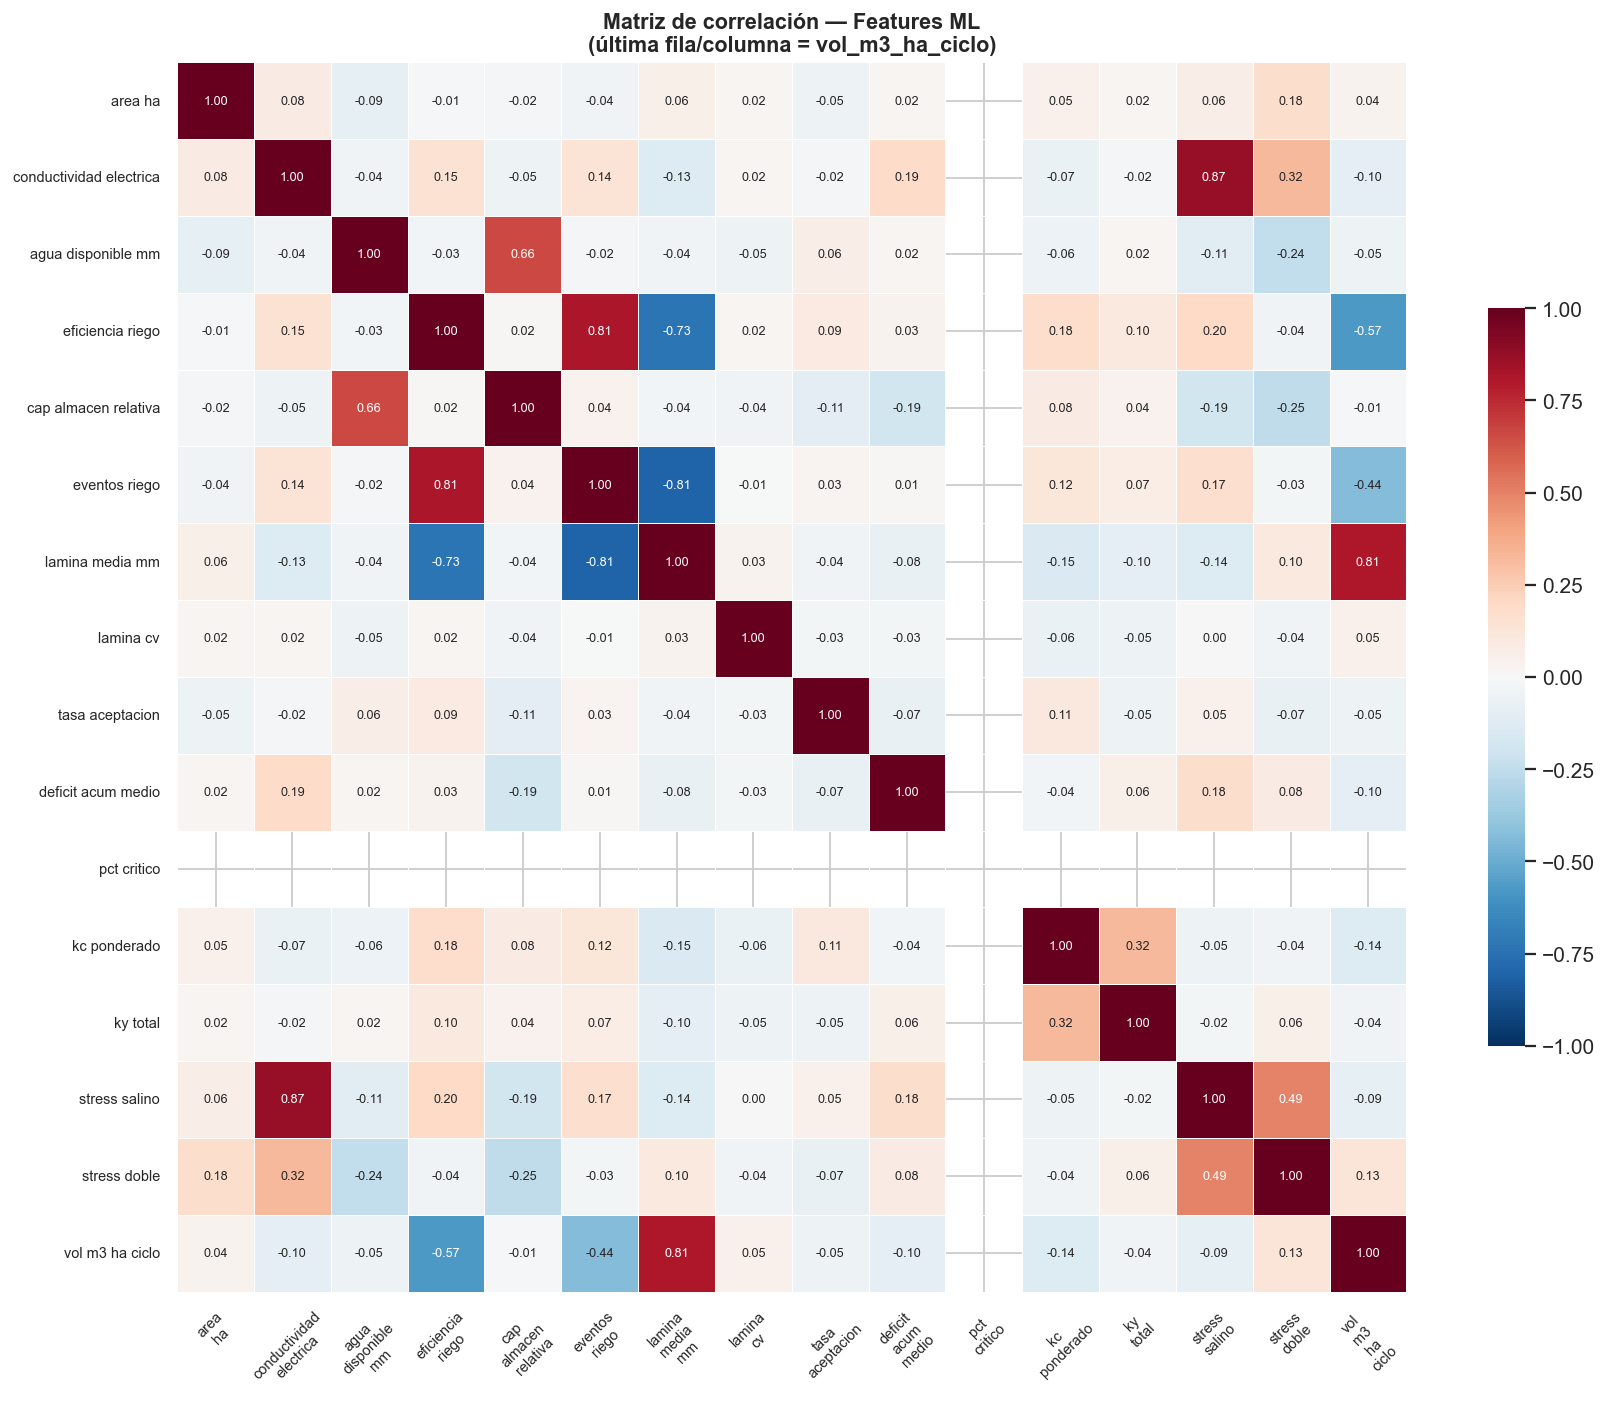

Feature,Correlación,|Correlación|,Dirección
lamina_media_mm,+0.809,0.809,+ (directa)
eficiencia_riego,-0.573,0.573,− (inversa)
eventos_riego,-0.436,0.436,− (inversa)
kc_ponderado,-0.137,0.137,− (inversa)
stress_doble,+0.130,0.130,+ (directa)
conductividad_electrica,-0.097,0.097,− (inversa)
deficit_acum_medio,-0.096,0.096,− (inversa)
stress_salino,-0.092,0.092,− (inversa)
agua_disponible_mm,-0.055,0.055,− (inversa)
lamina_cv,+0.051,0.051,+ (directa)


In [ ]:
# ── (a) Muestra estilizada ──────────────────────────────────────────────────
cols_show = [
    'id_parcela', 'ciclo_agricola', 'cultivo', 'sistema_riego',
    'area_ha', 'conductividad_electrica', 'agua_disponible_mm',
    'stress_salino', 'eficiencia_riego',
    'eventos_riego', 'vol_m3_ha_ciclo',
    'tasa_aceptacion', 'pct_critico',
    'kc_ponderado', 'ky_total',
    'meta_alcanzada', 'ahorro_potencial_mxn'
]
col_alias = [
    'ID Parcela', 'Ciclo', 'Cultivo', 'Sist. riego',
    'Área (ha)', 'CE (dS/m)', 'ADT (mm)',
    'Estrés sal.', 'Efic. riego',
    'N° eventos', 'Vol m³/ha/ciclo',
    'Tasa acept.', '% Crítico',
    'Kc pond.', 'Ky total',
    'Meta alcanzada', 'Ahorro pot. (MXN)'
]

muestra = feat[cols_show].head(15).copy().reset_index(drop=True)
muestra.columns = col_alias

def _hl_target(v):
    if v == 1:
        return 'background-color:#D5F5E3;color:#1E8449;font-weight:bold'
    return 'background-color:#FADBD8;color:#C0392B;font-weight:bold'

def _hl_stress(v):
    return 'background-color:#FADBD8;font-weight:bold' if v == 1 else ''

display(
    muestra.style
    .set_caption('🤖 Dataset ML — Primeras 15 filas (parcela × ciclo)')
    .map(_hl_target, subset=['Meta alcanzada'])
    .map(_hl_stress, subset=['Estrés sal.'])
    .background_gradient(subset=['Vol m³/ha/ciclo'], cmap='RdYlGn_r')
    .background_gradient(subset=['Ahorro pot. (MXN)'], cmap='Greens')
    .format({
        'Área (ha)':       '{:.1f}',
        'CE (dS/m)':       '{:.2f}',
        'ADT (mm)':        '{:.1f}',
        'Efic. riego':     '{:.2f}',
        'Vol m³/ha/ciclo': '{:,.0f}',
        'Tasa acept.':     '{:.0%}',
        '% Crítico':       '{:.0%}',
        'Kc pond.':        '{:.3f}',
        'Ky total':        '{:.2f}',
        'Ahorro pot. (MXN)': '${:,.0f}',
    })
    .set_properties(**{'text-align': 'center', 'font-size': '10px'})
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
    .hide(axis='index')
)

# ── (b) Estadísticas descriptivas ───────────────────────────────────────────
num_cols_desc = [
    'area_ha', 'conductividad_electrica', 'agua_disponible_mm',
    'eficiencia_riego', 'eventos_riego', 'vol_m3_ha_ciclo',
    'tasa_aceptacion', 'pct_critico',
    'kc_ponderado', 'ky_total',
    'meta_alcanzada', 'ahorro_potencial_mxn'
]
num_cols_desc = [c for c in num_cols_desc if c in feat.columns]
desc_ml = feat[num_cols_desc].describe().T

display(
    desc_ml.style
    .set_caption('Estadísticas descriptivas — Dataset ML (parcela × ciclo)')
    .background_gradient(subset=['mean'], cmap='Blues')
    .background_gradient(subset=['std'],  cmap='Oranges')
    .format('{:.3f}')
    .format('{:.0f}', subset=['count'])
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
)

# ── (c) Heatmap de correlación entre features ML y el target ────────────────
num_feats_ml = [
    'area_ha', 'conductividad_electrica', 'agua_disponible_mm',
    'eficiencia_riego', 'cap_almacen_relativa',
    'eventos_riego', 'lamina_media_mm', 'lamina_cv',
    'tasa_aceptacion', 'deficit_acum_medio', 'pct_critico',
    'kc_ponderado', 'ky_total',
    'stress_salino', 'stress_doble',
    'vol_m3_ha_ciclo'
]
num_feats_ml = [c for c in num_feats_ml if c in feat.columns]
corr_ml = feat[num_feats_ml].corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr_ml, ax=ax, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, linewidths=0.3,
    annot_kws={'size': 7},
    xticklabels=[c.replace('_', '\n') for c in corr_ml.columns],
    yticklabels=[c.replace('_', ' ') for c in corr_ml.index],
    square=True, cbar_kws={'shrink': 0.6}
)
ax.set_title(
    'Matriz de correlación — Features ML\n'
    '(última fila/columna = vol_m3_ha_ciclo)',
    fontsize=12, fontweight='bold'
)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.show()

# ── (d) Ranking de correlación con el target ─────────────────────────────────
target_corr = (
    corr_ml['vol_m3_ha_ciclo']
    .drop('vol_m3_ha_ciclo')
    .rename('corr')
    .reset_index()
    .rename(columns={'index': 'Feature'})
)
target_corr['|corr|'] = target_corr['corr'].abs()
target_corr['Dir.']   = target_corr['corr'].apply(
    lambda v: '+ (directa)' if v >= 0 else '− (inversa)'
)
target_corr = target_corr.sort_values('|corr|', ascending=False).reset_index(drop=True)
target_corr.columns = ['Feature', 'Correlación', '|Correlación|', 'Dirección']

display(
    target_corr.style
    .set_caption('Features por correlación absoluta con vol_m3_ha_ciclo')
    .background_gradient(subset=['|Correlación|'], cmap='Blues')
    .bar(subset=['Correlación'], color=[VERDE, ROJO], align='zero', vmin=-1, vmax=1)
    .format({'Correlación': '{:+.3f}', '|Correlación|': '{:.3f}'})
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '13px'), ('font-weight', 'bold')]}])
    .hide(axis='index')
)


---
## 12 · Vista Completa de Todos los Datasets

Exploración de cada tabla completa — todas las columnas, todas las filas disponibles
(con scroll horizontal). Útil para verificar calidad de datos y entender la
estructura real de cada dataset antes de modelar.

In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 12 — DataFrames completos de los 6 datasets
# ══════════════════════════════════════════════════════════════════════════════

from IPython.display import display, HTML

def mostrar_dataset(nombre, df, max_rows=None, caption_extra=''):
    """Muestra un dataset completo con estilo MILPÍN."""
    df_show = df if max_rows is None else df.head(max_rows)
    n_total = len(df)
    n_show  = len(df_show)
    
    titulo = (
        f"📋 {nombre} — {n_total:,} filas × {df.shape[1]} columnas"
        + (f" | mostrando {n_show}" if n_show < n_total else "")
        + (f" | {caption_extra}" if caption_extra else "")
    )
    
    # Detectar columnas numéricas para formato
    num_cols = df_show.select_dtypes(include='number').columns.tolist()
    
    styler = (
        df_show.reset_index(drop=True).style
        .set_caption(titulo)
        .set_properties(**{'text-align': 'center', 'font-size': '10px',
                           'white-space': 'nowrap'})
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size', '13px'), ('font-weight', 'bold'),
                       ('color', '#2C3E50'), ('text-align', 'left'),
                       ('padding', '8px 0')]},
            {'selector': 'th',
             'props': [('background-color', '#2C3E50'), ('color', 'white'),
                       ('padding', '6px 10px'), ('font-size', '10px'),
                       ('white-space', 'nowrap')]},
            {'selector': 'td',
             'props': [('padding', '5px 10px'), ('border-bottom', '1px solid #eee')]},
            {'selector': 'tr:nth-child(even)',
             'props': [('background-color', '#F8F9FA')]},
            {'selector': 'tr:hover',
             'props': [('background-color', '#EBF5FB')]},
        ])
    )
    if num_cols:
        styler = styler.format(
            {c: ('{:.2f}' if df_show[c].dtype == float else '{:,}')
             for c in num_cols},
            na_rep='—'
        )
    display(styler.hide(axis='index'))
    print()

print("=" * 70)
print("INVENTARIO COMPLETO DE DATOS — MILPÍN v2.0")
print("=" * 70)
print()

# 1. Usuarios
mostrar_dataset("👤 Usuarios", usuarios, caption_extra="agricultores del sistema")

# 2. Catálogo de cultivos
mostrar_dataset("🌾 Catálogo de Cultivos FAO-56", cultivos,
                caption_extra="parámetros agronómicos oficiales")

# 3. Parcelas (sin columna geom que es larga)
parc_display = parcelas.drop(columns=[c for c in ['geom'] if c in parcelas.columns], errors='ignore')
mostrar_dataset("🗺 Parcelas", parc_display,
                caption_extra="perfil edáfico y de riego por unidad")

# 4. Historial de riego — muestra 100 filas (son miles)
mostrar_dataset("💧 Historial de Riego", historial, max_rows=100,
                caption_extra=f"mostrando 100 de {len(historial):,} eventos totales")

# 5. Recomendaciones — muestra 100 filas
rec_display = recomend.drop(columns=['parametros_json'], errors='ignore')
mostrar_dataset("🤖 Recomendaciones FAO-56", rec_display, max_rows=100,
                caption_extra=f"mostrando 100 de {len(recomend):,} recomendaciones")

# 6. Costos por ciclo
mostrar_dataset("💰 Costos por Ciclo Agrícola", costos,
                caption_extra="estructura económica completa")

print("✓ Exploración completa finalizada.")


INVENTARIO COMPLETO DE DATOS — MILPÍN v2.0



id_usuario,nombre_completo,email,telefono,modulo_dr041,activo,created_at
66dc7715-a8ed-48c7-908b-83f76b01312e,Ramón Valenzuela,ramon.valenzuela000@dr041-dev.com,"526,441,803,258",Módulo 4,True,2025-01-22T16:57:03+00:00
641616f1-6d0a-4fa6-9a0a-29c1bb2d84a6,María Fernández,maria.fernandez001@dr041-dev.com,"526,448,727,380",Módulo 1,True,2024-12-22T23:17:03+00:00
d04b7eb5-cb55-46ff-94f2-cf982296b5b2,Juan Carlos Ortiz,juan.carlos.ortiz002@dr041-dev.com,"526,445,738,310",Módulo 5,True,2024-11-25T08:39:03+00:00
4dfb1bcc-997a-41a2-825d-78c9fc95044d,Luis Miranda,luis.miranda003@dr041-dev.com,"526,448,074,577",Módulo 3,True,2026-02-05T06:55:03+00:00
eef355b8-2cc5-4979-8c38-150728a4e340,Rosa Herrera,rosa.herrera004@dr041-dev.com,"526,445,503,166",Módulo 2,True,2025-12-28T04:36:03+00:00
bec519f0-27d3-40aa-8702-3f9daf62b70e,Jesús Soto,jesus.soto005@dr041-dev.com,"526,446,794,785",Módulo 3,True,2024-09-23T13:56:03+00:00
dbb7ddd7-c750-4d47-90f6-6106783ab3db,Guadalupe Ríos,guadalupe.rios006@dr041-dev.com,"526,445,054,135",Módulo 2,True,2026-03-03T13:29:03+00:00
d19da600-9b60-4031-9214-2a167ddb3898,Alejandro Castillo,alejandro.castillo007@dr041-dev.com,"526,441,574,355",Módulo 5,True,2024-09-20T20:45:03+00:00
774d6b2a-61bc-4796-81e5-b039bdfbd52c,Norma Reyes,norma.reyes008@dr041-dev.com,"526,442,487,061",Módulo 4,True,2024-12-20T19:18:03+00:00
4b54daf2-987b-4059-a1b6-5e2a1983d28c,Sergio Bojórquez,sergio.bojorquez009@dr041-dev.com,"526,449,736,281",Módulo 3,True,2024-08-03T10:36:03+00:00


id_cultivo,nombre_comun,nombre_cientifico,kc_inicial,kc_medio,kc_final,ky_total,dias_etapa_inicial,dias_etapa_desarrollo,dias_etapa_media,dias_etapa_final,rendimiento_potencial_ton
b1c20edc-4510-4002-a730-5ad4356dba91,Maíz,Zea mays,0.30,1.20,0.60,1.25,25,40,45,30,10.00
b6e29a2a-a7a6-4cfc-b00d-0dbb8304729d,Frijol,Phaseolus vulgaris,0.40,1.15,0.35,1.15,20,30,40,20,2.00
0f3f1ca9-4c69-43ae-85c5-6d898bb6fe99,Algodón,Gossypium hirsutum,0.35,1.20,0.70,0.85,30,50,55,45,3.50
835d37d0-113b-4f76-a102-005e5bf14054,Uva,Vitis vinifera,0.30,0.85,0.45,0.85,30,60,75,50,22.50
3fae9720-89c2-4356-adb9-cd54f91d3882,Chile,Capsicum annuum,0.60,1.05,0.90,1.10,30,35,40,20,30.00


id_parcela,id_usuario,id_cultivo_actual,nombre_parcela,area_ha,tipo_suelo,conductividad_electrica,profundidad_raiz_cm,capacidad_campo,punto_marchitez,sistema_riego,activo,created_at,cultivo,agua_disponible_mm
63b4f127-a33b-462d-94a1-1b5da940952d,4dfb1bcc-997a-41a2-825d-78c9fc95044d,b1c20edc-4510-4002-a730-5ad4356dba91,Lote Maí-001,18.89,arcilloso,1.18,99,0.30,0.22,gravedad,True,2025-07-05T10:32:03+00:00,Frijol,81.68
ce83cb07-58f6-4daf-a6e3-1ee72480447b,4b54daf2-987b-4059-a1b6-5e2a1983d28c,b1c20edc-4510-4002-a730-5ad4356dba91,Lote Maí-002,12.55,franco,1.66,126,0.25,0.09,aspersion,True,2026-02-10T03:31:03+00:00,Algodón,199.33
5ddf7399-e390-4a8e-ace0-651a67542da2,bec519f0-27d3-40aa-8702-3f9daf62b70e,b6e29a2a-a7a6-4cfc-b00d-0dbb8304729d,Lote Fri-003,14.56,arenoso,3.65,90,0.24,0.16,microaspersion,True,2025-06-18T02:01:03+00:00,Chile,73.35
eebee71b-b00b-4a44-b941-73e1c260c706,3df7dd0d-8656-4a87-9657-e5b6465bf9fd,3fae9720-89c2-4356-adb9-cd54f91d3882,Lote Chi-004,18.30,arcilloso,2.09,146,0.30,0.13,gravedad,True,2025-06-18T14:58:03+00:00,Frijol,246.45
b1da7fe5-e177-4f94-81e5-3dad69d2c13d,86da88b3-dbc3-4bdf-89ec-0d84cbf360fe,b6e29a2a-a7a6-4cfc-b00d-0dbb8304729d,Lote Fri-005,9.69,franco-arenoso,1.51,126,0.26,0.13,gravedad,True,2025-11-02T11:13:03+00:00,Chile,160.90
85be4752-4bd9-4eff-a359-e17047ad49e1,77890133-fd37-4e83-b67d-0a80b3e059ca,835d37d0-113b-4f76-a102-005e5bf14054,Lote Uva-006,8.76,franco-arenoso,1.67,126,0.30,0.09,microaspersion,True,2025-11-18T23:47:03+00:00,Algodón,260.44
ddc49f6a-26d2-449f-b5f9-028051bf0aee,eef355b8-2cc5-4979-8c38-150728a4e340,b1c20edc-4510-4002-a730-5ad4356dba91,Lote Maí-007,7.83,arcilloso,3.86,114,0.34,0.17,gravedad,True,2026-02-05T00:23:03+00:00,Uva,186.28
bbe0d9f4-8075-4afd-a43e-5602f914bd48,bec519f0-27d3-40aa-8702-3f9daf62b70e,b1c20edc-4510-4002-a730-5ad4356dba91,Lote Maí-008,9.99,franco-limoso,2.88,189,0.31,0.17,gravedad,True,2025-06-27T13:29:03+00:00,Chile,270.27
84cb8d9b-98e2-45bd-9d7e-beb70a27b3fa,641616f1-6d0a-4fa6-9a0a-29c1bb2d84a6,3fae9720-89c2-4356-adb9-cd54f91d3882,Lote Chi-009,32.58,franco-arcilloso,4.77,81,0.30,0.24,gravedad,True,2025-12-12T16:47:03+00:00,Uva,50.14
6906ce52-e8b0-4489-ac75-5548d7c2b754,d04b7eb5-cb55-46ff-94f2-cf982296b5b2,b6e29a2a-a7a6-4cfc-b00d-0dbb8304729d,Lote Fri-010,6.73,franco-arcilloso,1.86,158,0.27,0.12,gravedad,True,2026-04-30T00:09:03+00:00,Maíz,234.47


id_riego,id_parcela,ciclo_agricola,id_recomendacion,fecha_riego,volumen_m3_ha,lamina_mm,duracion_horas,metodo_riego,origen_decision,costo_energia_mxn,ciclo_vol_target_m3_ha,observaciones,created_at
75a454c5-92ff-4c98-a9df-1104b2169825,63b4f127-a33b-462d-94a1-1b5da940952d,OI-2021,809f5ab5-7fc7-4f5f-8adc-5dd152336871,2020-10-24 00:00:00,673.55,67.36,13.19,gravedad,sistema,22669.47,6192.85,—,2020-10-24T14:58:00+00:00
dc94c400-c995-4b8e-b492-9bfa99e8e10e,63b4f127-a33b-462d-94a1-1b5da940952d,OI-2021,—,2020-10-30 00:00:00,972.49,97.25,16.50,gravedad,sistema,28463.06,6192.85,—,2020-10-30T18:00:00+00:00
fd743f63-edd7-48d9-88d8-8ae9083d3004,63b4f127-a33b-462d-94a1-1b5da940952d,OI-2021,—,2020-11-04 00:00:00,245.90,24.59,4.15,gravedad,sistema,8839.13,6192.85,—,2020-11-04T08:14:00+00:00
f11def1e-ddf8-493a-a5da-c91c72e4b8c0,63b4f127-a33b-462d-94a1-1b5da940952d,OI-2021,17d79926-85f9-4879-b105-ce7692c26ead,2020-11-14 00:00:00,563.65,56.37,11.22,gravedad,voz,15741.00,6192.85,—,2020-11-14T08:41:00+00:00
e3442654-73b7-4928-a1f9-42a411c552d7,63b4f127-a33b-462d-94a1-1b5da940952d,OI-2021,587be71f-5bc5-4e51-87b7-ac1fd977d112,2021-01-20 00:00:00,791.12,79.11,13.66,gravedad,voz,27418.21,6192.85,—,2021-01-20T14:11:00+00:00
6d6b7538-d94e-42c0-a07f-6b5ccdc91196,63b4f127-a33b-462d-94a1-1b5da940952d,OI-2021,a5f6d749-b9b2-4f24-aca3-b20b0a2b7987,2021-01-20 00:00:00,398.56,39.86,8.17,gravedad,manual,13231.36,6192.85,—,2021-01-20T10:03:00+00:00
4366b015-842f-4eec-a255-fac0fde8e372,63b4f127-a33b-462d-94a1-1b5da940952d,OI-2021,—,2021-02-08 00:00:00,1219.16,121.92,20.81,gravedad,manual,43566.28,6192.85,—,2021-02-08T07:28:00+00:00
6270fd1e-1e5f-4ed3-b7a2-9549c235f1a1,63b4f127-a33b-462d-94a1-1b5da940952d,OI-2021,626271c3-54f8-4224-829b-562ed315b074,2021-02-25 00:00:00,614.39,61.44,15.93,gravedad,manual,20770.82,6192.85,—,2021-02-25T10:23:00+00:00
ed79c959-f520-4d6b-985d-69096697e0c3,63b4f127-a33b-462d-94a1-1b5da940952d,OI-2021,—,2021-02-27 00:00:00,714.02,71.40,16.15,gravedad,voz,19995.18,6192.85,—,2021-02-27T08:45:00+00:00
7c76f363-b2e5-4752-938a-8e570481d5f6,63b4f127-a33b-462d-94a1-1b5da940952d,PV-2021,798c80d9-9e83-46b8-a50a-144afefaa3a6,2021-04-02 00:00:00,233.07,23.31,3.95,gravedad,manual,6986.10,7183.77,—,2021-04-02T17:05:00+00:00


id_recomendacion,id_parcela,id_cultivo,fecha_generacion,fecha_riego_sugerida,lamina_recomendada_mm,eto_referencia,etc_calculada,deficit_acumulado_mm,dias_sin_riego,nivel_urgencia,algoritmo_version,aceptada,lamina_ejecutada_mm,cultivo,mes
9ee4ac38-eff2-45ca-9f44-7a49eb6582ad,63b4f127-a33b-462d-94a1-1b5da940952d,0f3f1ca9-4c69-43ae-85c5-6d898bb6fe99,2023-08-21 10:14:03+00:00,2023-08-24,31.75,6.54,4.29,74.91,13,moderado,fao56-v0.2,modificada,35.65,Algodón,2023-08
394ee637-f454-440b-8a56-4abb8bc8ab71,63b4f127-a33b-462d-94a1-1b5da940952d,3fae9720-89c2-4356-adb9-cd54f91d3882,2022-04-15 00:02:03+00:00,2022-04-21,60.50,5.22,4.92,47.40,16,moderado,fao56-v0.2,aceptada,60.50,Chile,2022-04
2c2aa9d1-9a87-46c2-9585-be33789b3f6e,63b4f127-a33b-462d-94a1-1b5da940952d,3fae9720-89c2-4356-adb9-cd54f91d3882,2023-01-24 07:24:03+00:00,2023-01-26,67.52,3.56,3.09,26.22,3,preventivo,fao56-v0.2,aceptada,67.52,Chile,2023-01
944b37c7-f6f0-4677-9c8f-f4d65c16b8f0,63b4f127-a33b-462d-94a1-1b5da940952d,0f3f1ca9-4c69-43ae-85c5-6d898bb6fe99,2021-07-05 08:06:03+00:00,2021-07-07,140.80,2.47,2.35,20.70,9,preventivo,fao56-v0.2,ignorada,—,Algodón,2021-07
f4b12e28-305c-4b7e-9382-82063d017dba,63b4f127-a33b-462d-94a1-1b5da940952d,0f3f1ca9-4c69-43ae-85c5-6d898bb6fe99,2022-04-27 09:40:03+00:00,2022-05-03,101.21,4.01,1.99,95.94,17,critico,fao56-v0.2,aceptada,101.21,Algodón,2022-04
7dfd5f53-3ab3-4faf-8cff-62b99c1d7faa,63b4f127-a33b-462d-94a1-1b5da940952d,b1c20edc-4510-4002-a730-5ad4356dba91,2025-08-27 17:14:03+00:00,2025-08-31,107.83,10.31,4.80,62.45,15,moderado,fao56-v0.2,aceptada,107.83,Maíz,2025-08
2d7ea53f-f47b-4ee5-a4db-2781a0676e02,63b4f127-a33b-462d-94a1-1b5da940952d,0f3f1ca9-4c69-43ae-85c5-6d898bb6fe99,2025-03-14 00:14:03+00:00,2025-03-21,61.72,6.89,6.76,67.54,7,moderado,fao56-v0.2,ignorada,—,Algodón,2025-03
07aa0bc7-86ba-48a4-90af-8646ac4db179,63b4f127-a33b-462d-94a1-1b5da940952d,835d37d0-113b-4f76-a102-005e5bf14054,2021-10-23 09:52:03+00:00,2021-10-26,72.01,10.23,5.77,78.37,5,moderado,fao56-v0.2,pendiente,—,Uva,2021-10
d92bf8d3-0df4-4c6b-bc0c-99319410a140,63b4f127-a33b-462d-94a1-1b5da940952d,b6e29a2a-a7a6-4cfc-b00d-0dbb8304729d,2025-05-19 05:43:03+00:00,2025-05-24,41.74,8.03,6.90,57.82,7,moderado,fao56-v0.2,aceptada,41.74,Frijol,2025-05
b1e2c246-8e2e-4df8-9c7a-656f4234ded6,63b4f127-a33b-462d-94a1-1b5da940952d,0f3f1ca9-4c69-43ae-85c5-6d898bb6fe99,2025-05-30 06:37:03+00:00,2025-05-31,78.41,8.96,3.17,5.21,3,preventivo,fao56-v0.2,modificada,62.56,Algodón,2025-05



✓ Exploración completa finalizada.


---
## 13 · Línea de Tiempo — Ciclos Agrícolas 2020-2025

El DR-041 opera con **dos ciclos por año**:
- **OI** (Otoño-Invierno): octubre → marzo
- **PV** (Primavera-Verano): abril → septiembre

Los datos cubren **10 ciclos** completos: OI-2021 a OI-2025 y PV-2021 a PV-2025.

Ciclo,Inicio,Fin,N° eventos,Vol medio (m³/ha),% bajo meta 6k,Parcelas
OI-2021,2020-10-15,2021-03-14,"1,141","8,002",16.2%,80
PV-2021,2021-04-01,2021-09-14,"1,132","8,220",21.2%,80
OI-2022,2021-10-15,2022-03-14,"1,103","8,057",17.5%,80
PV-2022,2022-04-01,2022-09-14,"1,129","8,196",13.8%,80
OI-2023,2022-10-15,2023-03-14,"1,124","8,270",20.0%,80
PV-2023,2023-04-01,2023-09-14,"1,173","8,228",13.8%,80
OI-2024,2023-10-15,2024-03-14,"1,129","8,414",18.8%,80
PV-2024,2024-04-01,2024-09-14,"1,092","7,755",22.5%,80
OI-2025,2024-10-15,2025-03-14,"1,110","8,287",10.0%,80
PV-2025,2025-04-01,2025-09-14,"1,075","8,190",25.0%,80


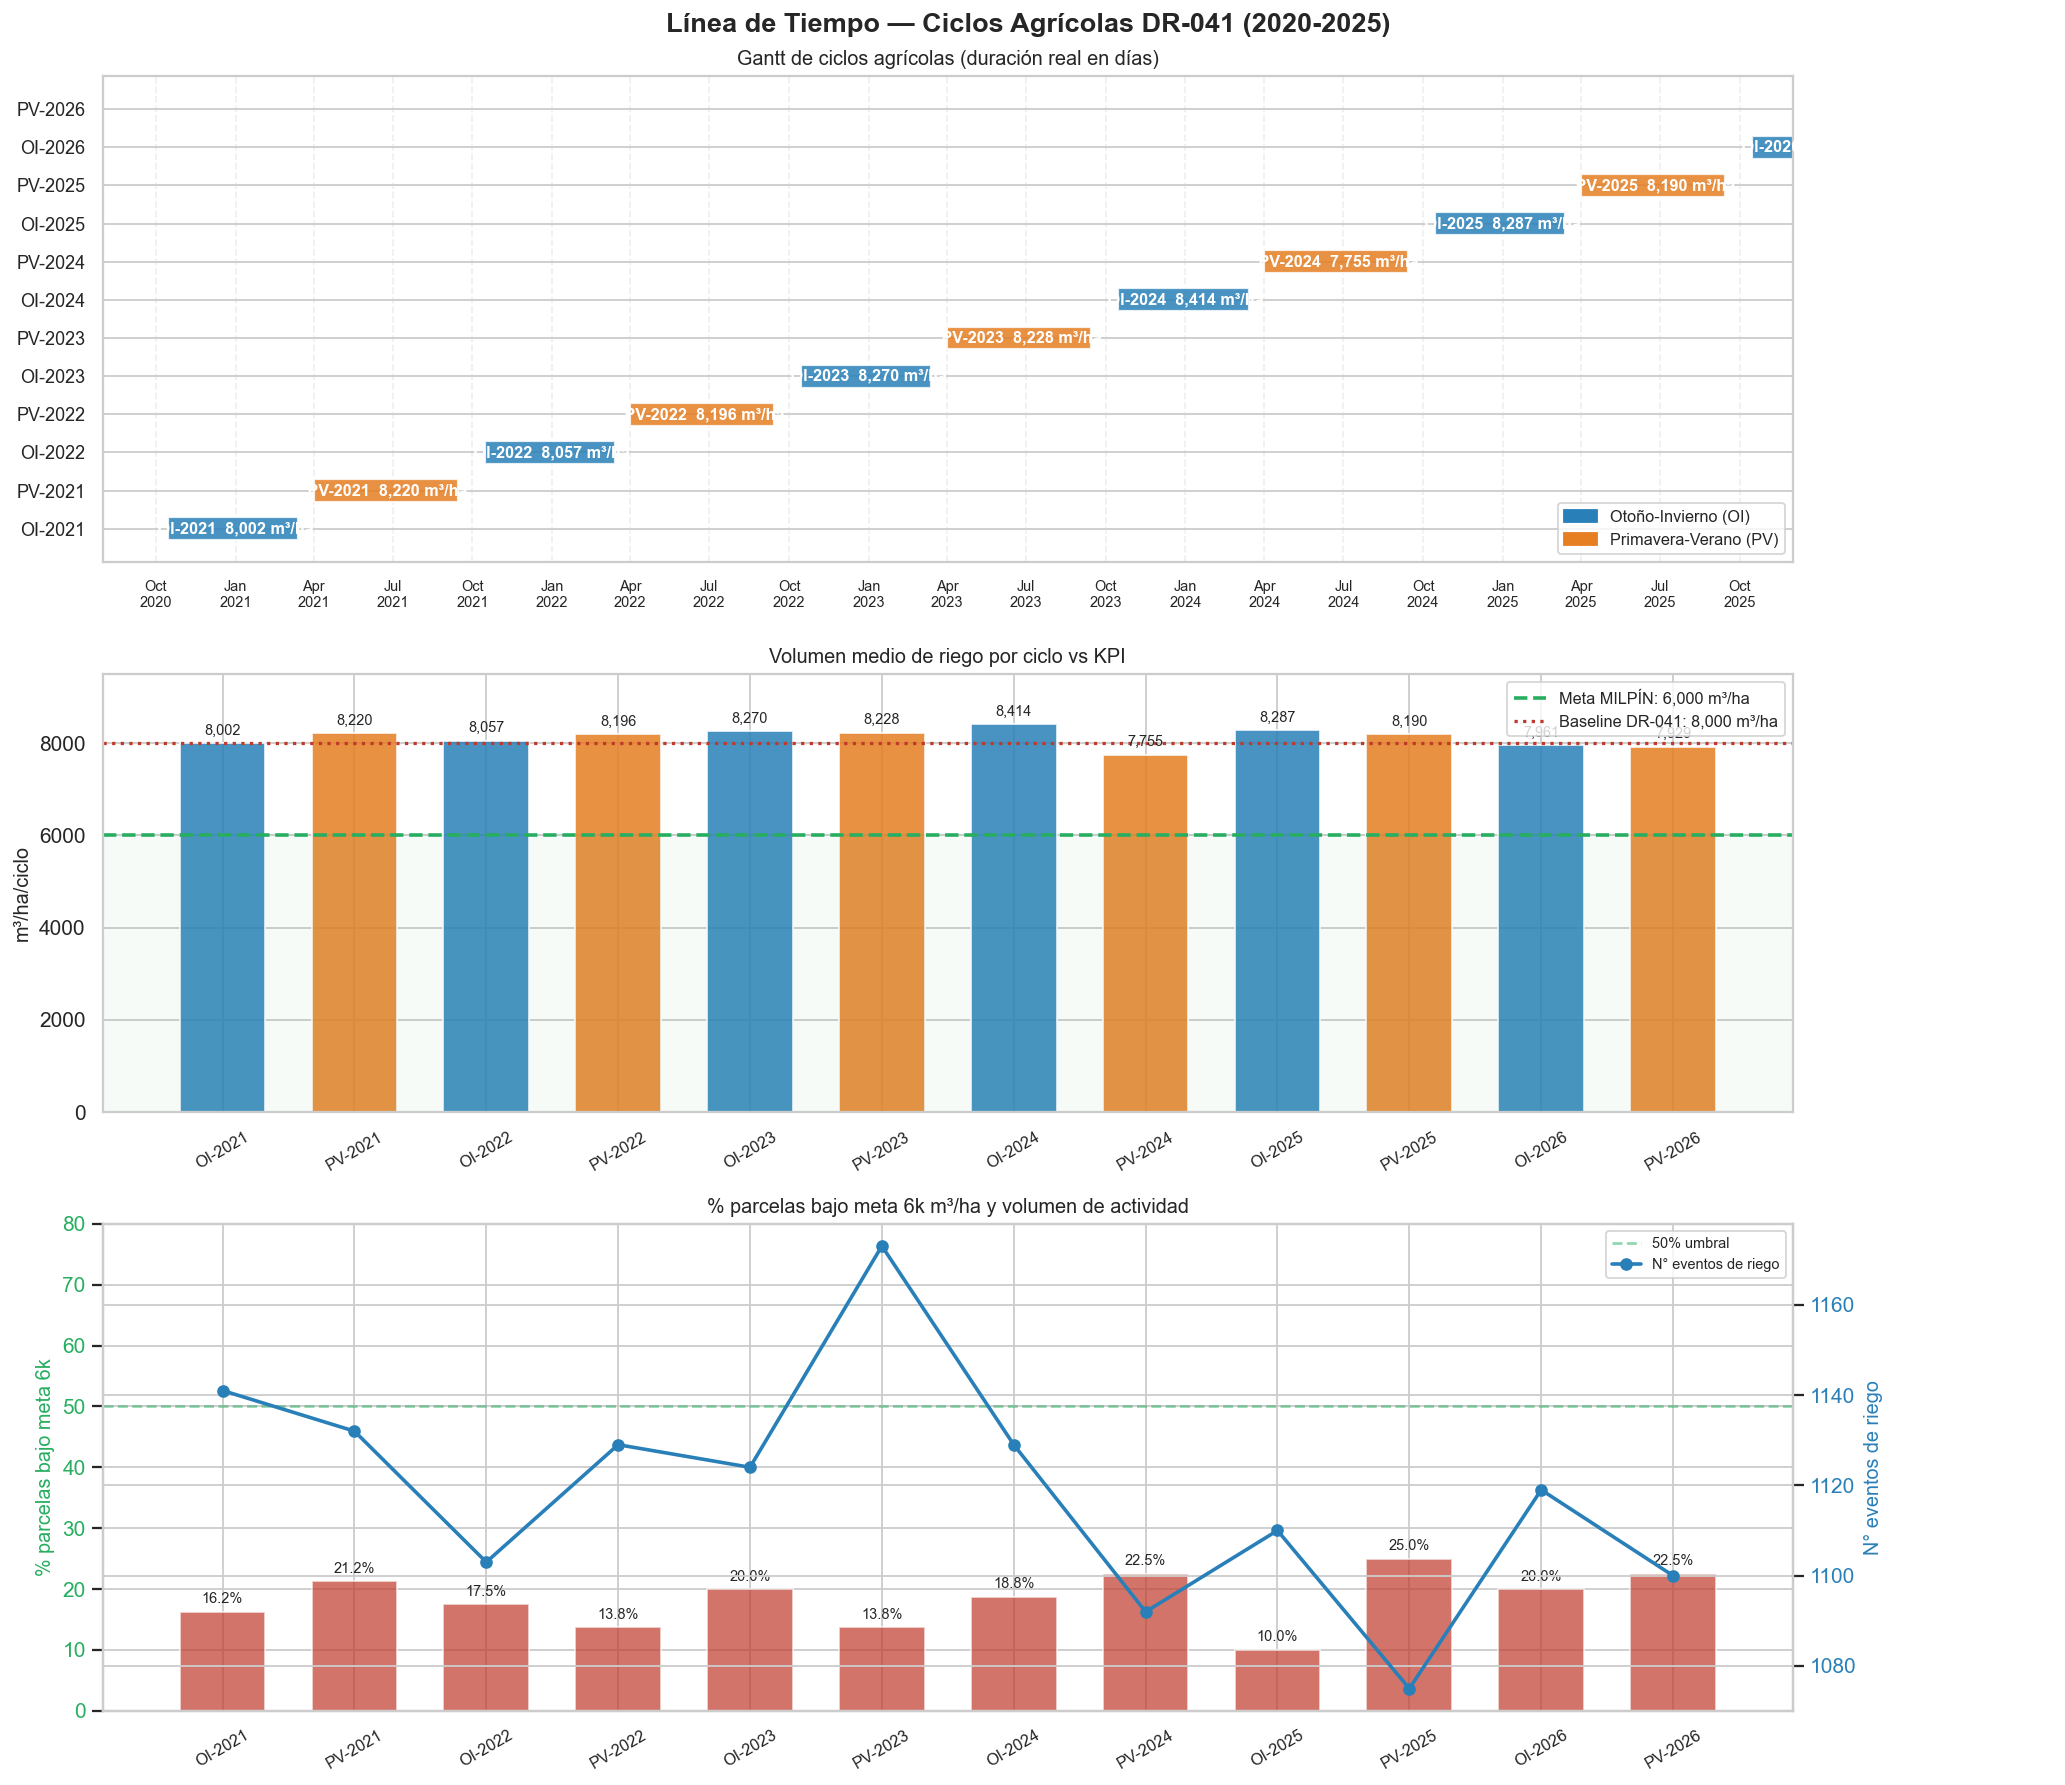

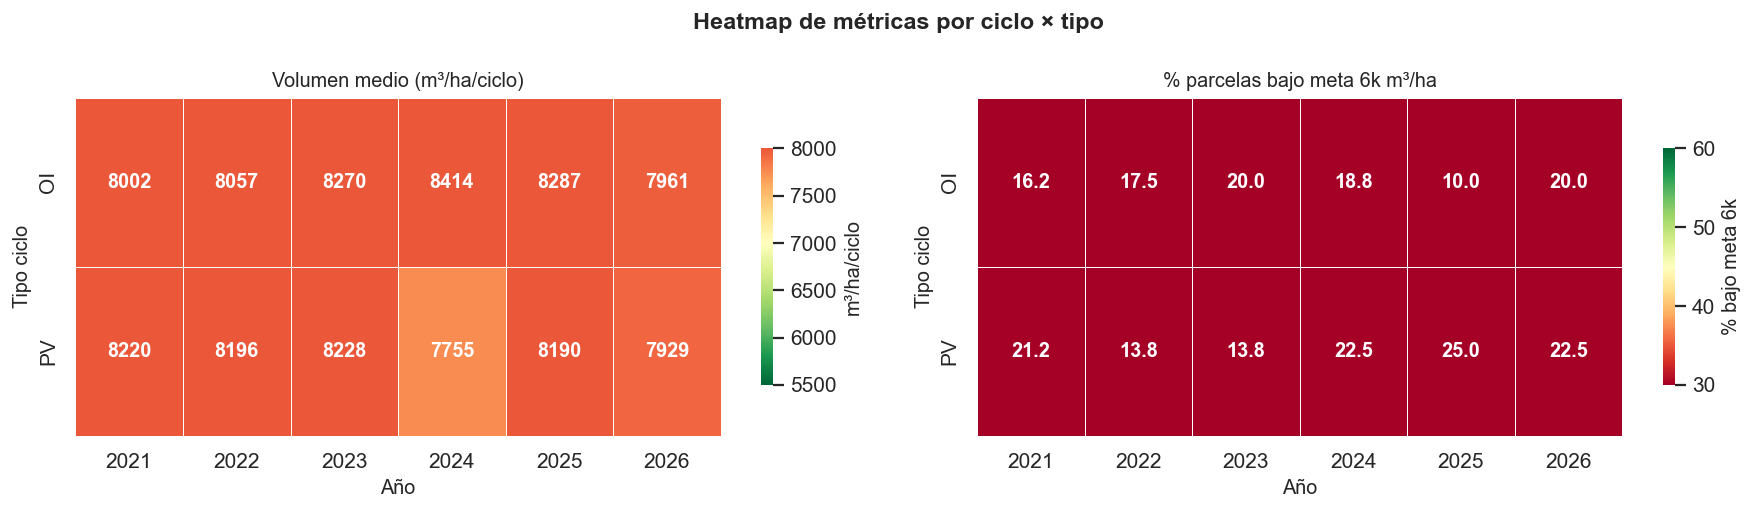


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
RESUMEN DE LA SERIE TEMPORAL
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Periodo cubierto : 2020-10-15 → 2026-09-14
  Total ciclos     : 12 (6 OI + 6 PV)
  Total eventos    : 13,427 registros de riego
  Vol. global medio: 8,126 m³/ha/ciclo
  Ahorro vs 8k     : -1.6%
  Tendencia vol    : -0.210 (corr con orden)

  Mejor ciclo      : PV-2024 — 7,755 m³/ha
  Peor ciclo       : OI-2024  — 8,414 m³/ha


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 13 — Línea de tiempo de ciclos agrícolas
# ══════════════════════════════════════════════════════════════════════════════

import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

# ── Preparar datos de timeline ────────────────────────────────────────────────
ciclo_info = (
    historial
    .groupby('ciclo_agricola')
    .agg(
        fecha_inicio=('fecha_riego', 'min'),
        fecha_fin   =('fecha_riego', 'max'),
        n_eventos   =('id_riego',    'count'),
        vol_medio   =('volumen_m3_ha','mean'),
    )
    .reset_index()
)
# KPI por ciclo (vol total parcela×ciclo)
kpi_ciclo = (
    kpi.groupby('ciclo_agricola')
    .agg(
        vol_ciclo_medio=('vol_m3_ha_ciclo','mean'),
        pct_bajo_meta  =('bajo_meta',      lambda x: x.mean()*100),
        n_parcelas     =('id_parcela',      'count'),
    )
    .reset_index()
)
ciclo_info = ciclo_info.merge(kpi_ciclo, on='ciclo_agricola', how='left')
ciclo_info['tipo'] = ciclo_info['ciclo_agricola'].str[:2]   # OI / PV
ciclo_info['año']  = ciclo_info['ciclo_agricola'].str[-4:].astype(int)
ciclo_info = ciclo_info.sort_values('fecha_inicio').reset_index(drop=True)

# Mostrar tabla resumen de ciclos
tabla_ciclos = ciclo_info[[
    'ciclo_agricola','fecha_inicio','fecha_fin',
    'n_eventos','vol_ciclo_medio','pct_bajo_meta','n_parcelas'
]].copy()
tabla_ciclos.columns = [
    'Ciclo','Inicio','Fin',
    'N° eventos','Vol medio (m³/ha)','% bajo meta 6k','Parcelas'
]

def _color_vol(v):
    if v <= 6000: return 'background-color:#D5F5E3;color:#1E8449;font-weight:bold'
    if v <= 7000: return 'background-color:#FDEBD0;color:#E67E22;font-weight:bold'
    return 'background-color:#FADBD8;color:#C0392B;font-weight:bold'

display(
    tabla_ciclos.style
    .set_caption('Resumen de ciclos agrícolas — DR-041 Módulo 3')
    .map(_color_vol, subset=['Vol medio (m³/ha)'])
    .background_gradient(subset=['% bajo meta 6k'], cmap='Greens')
    .format({
        'Inicio':          '{:%Y-%m-%d}',
        'Fin':             '{:%Y-%m-%d}',
        'N° eventos':      '{:,d}',
        'Vol medio (m³/ha)': '{:,.0f}',
        '% bajo meta 6k':   '{:.1f}%',
        'Parcelas':         '{:d}',
    })
    .set_properties(**{'text-align':'center'})
    .set_table_styles([{'selector':'caption',
                        'props':[('font-size','14px'),('font-weight','bold')]}])
    .hide(axis='index')
)

# ── Gráfico 1: Gantt de ciclos ────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 14),
                          gridspec_kw={'height_ratios':[2, 1.8, 2]})
fig.suptitle('Línea de Tiempo — Ciclos Agrícolas DR-041 (2020-2025)',
             fontsize=15, fontweight='bold', y=0.98)

COLOR_OI = '#2980B9'   # azul  → Otoño-Invierno
COLOR_PV = '#E67E22'   # naranja → Primavera-Verano
COLOR_META = '#27AE60'
COLOR_BASE = '#C0392B'

# ─ Panel 1: Gantt Horizontal ─────────────────────────────────────────────────
ax1 = axes[0]
yticks, ylabels = [], []
for i, row in ciclo_info.iterrows():
    color = COLOR_OI if row['tipo'] == 'OI' else COLOR_PV
    ax1.barh(y=i, left=row['fecha_inicio'], 
             width=(row['fecha_fin'] - row['fecha_inicio']).days,
             color=color, alpha=0.85, height=0.6, edgecolor='white', linewidth=1.2)
    # Etiqueta dentro de la barra
    mid = row['fecha_inicio'] + (row['fecha_fin'] - row['fecha_inicio']) / 2
    ax1.text(mid, i, f' {row["ciclo_agricola"]}  {row["vol_ciclo_medio"]:,.0f} m³/ha',
             ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    yticks.append(i)
    ylabels.append(row['ciclo_agricola'])

ax1.set_yticks(yticks)
ax1.set_yticklabels(ylabels, fontsize=10)
ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax1.set_xlim(pd.Timestamp('2020-08-01'), pd.Timestamp('2025-12-01'))
ax1.set_title('Gantt de ciclos agrícolas (duración real en días)', fontsize=11)
ax1.tick_params(axis='x', labelsize=8)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
legend_patch = [
    mpatches.Patch(color=COLOR_OI, label='Otoño-Invierno (OI)'),
    mpatches.Patch(color=COLOR_PV, label='Primavera-Verano (PV)'),
]
ax1.legend(handles=legend_patch, fontsize=9, loc='lower right')

# ─ Panel 2: Volumen medio por ciclo (barras) ─────────────────────────────────
ax2 = axes[1]
x_pos = range(len(ciclo_info))
colors_bar = [COLOR_OI if t=='OI' else COLOR_PV for t in ciclo_info['tipo']]
bars = ax2.bar(x_pos, ciclo_info['vol_ciclo_medio'], color=colors_bar,
               alpha=0.85, edgecolor='white', width=0.65)
ax2.bar_label(bars, fmt='{:,.0f}', fontsize=8, padding=3)
ax2.axhline(6000, color=COLOR_META, linestyle='--', lw=2,
            label=f'Meta MILPÍN: 6,000 m³/ha')
ax2.axhline(8000, color=COLOR_BASE, linestyle=':', lw=1.8,
            label=f'Baseline DR-041: 8,000 m³/ha')
ax2.set_xticks(list(x_pos))
ax2.set_xticklabels(ciclo_info['ciclo_agricola'], rotation=30, fontsize=9)
ax2.set_ylabel('m³/ha/ciclo')
ax2.set_title('Volumen medio de riego por ciclo vs KPI', fontsize=11)
ax2.legend(fontsize=9)
ax2.set_ylim(0, 9500)

# Zona de meta (sombreado verde)
ax2.axhspan(0, 6000, alpha=0.04, color=COLOR_META)

# ─ Panel 3: % ciclos bajo meta + evolución temporal ─────────────────────────
ax3 = axes[2]
ax3b = ax3.twinx()

# Barras: % parcelas bajo meta
colors_pct = [COLOR_META if p >= 45 else NARANJA if p >= 35 else ROJO
              for p in ciclo_info['pct_bajo_meta']]
bars3 = ax3.bar(x_pos, ciclo_info['pct_bajo_meta'], color=colors_pct,
                alpha=0.70, edgecolor='white', width=0.65)
ax3.bar_label(bars3, fmt='{:.1f}%', fontsize=8, padding=3)
ax3.set_ylabel('% parcelas bajo meta 6k', color=COLOR_META)
ax3.tick_params(axis='y', labelcolor=COLOR_META)
ax3.set_ylim(0, 80)
ax3.axhline(50, color=COLOR_META, linestyle='--', lw=1.5, alpha=0.5,
            label='50% umbral')

# Línea: eventos por ciclo
ax3b.plot(list(x_pos), ciclo_info['n_eventos'], color=AZUL, lw=2,
          marker='o', ms=6, label='N° eventos de riego')
ax3b.set_ylabel('N° eventos de riego', color=AZUL)
ax3b.tick_params(axis='y', labelcolor=AZUL)

ax3.set_xticks(list(x_pos))
ax3.set_xticklabels(ciclo_info['ciclo_agricola'], rotation=30, fontsize=9)
ax3.set_title('% parcelas bajo meta 6k m³/ha y volumen de actividad', fontsize=11)

lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

# ── Gráfico 2: Heatmap ciclo × año ───────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 4))
fig2.suptitle('Heatmap de métricas por ciclo × tipo', fontsize=13, fontweight='bold')

pivot_vol = ciclo_info.pivot_table(index='tipo', columns='año',
                                    values='vol_ciclo_medio', aggfunc='mean')
pivot_pct = ciclo_info.pivot_table(index='tipo', columns='año',
                                    values='pct_bajo_meta', aggfunc='mean')

sns.heatmap(pivot_vol, ax=axes2[0], annot=True, fmt='.0f', cmap='RdYlGn_r',
            center=7000, vmin=5500, vmax=8000, linewidths=0.5,
            annot_kws={'size':11, 'weight':'bold'},
            cbar_kws={'label':'m³/ha/ciclo','shrink':0.7})
axes2[0].set_title('Volumen medio (m³/ha/ciclo)', fontsize=11)
axes2[0].set_xlabel('Año'); axes2[0].set_ylabel('Tipo ciclo')

sns.heatmap(pivot_pct, ax=axes2[1], annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=30, vmax=60, linewidths=0.5,
            annot_kws={'size':11, 'weight':'bold'},
            cbar_kws={'label':'% bajo meta 6k','shrink':0.7})
axes2[1].set_title('% parcelas bajo meta 6k m³/ha', fontsize=11)
axes2[1].set_xlabel('Año'); axes2[1].set_ylabel('Tipo ciclo')

plt.tight_layout()
plt.show()

# ── Resumen estadístico de la serie temporal ──────────────────────────────────
print()
print("━" * 60)
print("RESUMEN DE LA SERIE TEMPORAL")
print("━" * 60)
print(f"  Periodo cubierto : {ciclo_info['fecha_inicio'].min():%Y-%m-%d}"
      f" → {ciclo_info['fecha_fin'].max():%Y-%m-%d}")
print(f"  Total ciclos     : {len(ciclo_info)} ({ciclo_info['tipo'].value_counts()['OI']} OI + {ciclo_info['tipo'].value_counts()['PV']} PV)")
print(f"  Total eventos    : {ciclo_info['n_eventos'].sum():,} registros de riego")
print(f"  Vol. global medio: {ciclo_info['vol_ciclo_medio'].mean():,.0f} m³/ha/ciclo")
print(f"  Ahorro vs 8k     : {(8000 - ciclo_info['vol_ciclo_medio'].mean()) / 8000 * 100:.1f}%")
print(f"  Tendencia vol    : {ciclo_info['vol_ciclo_medio'].corr(pd.Series(range(len(ciclo_info)))):.3f} (corr con orden)")
print()
mejor = ciclo_info.loc[ciclo_info['vol_ciclo_medio'].idxmin()]
peor  = ciclo_info.loc[ciclo_info['vol_ciclo_medio'].idxmax()]
print(f"  Mejor ciclo      : {mejor['ciclo_agricola']} — {mejor['vol_ciclo_medio']:,.0f} m³/ha")
print(f"  Peor ciclo       : {peor['ciclo_agricola']}  — {peor['vol_ciclo_medio']:,.0f} m³/ha")


---
## 14 · Panel EDA — Distribuciones y Correlaciones

Panel de 6 gráficas que caracterizan el comportamiento climático
del dataset sintético `milpin_ciclos_ml.csv` (Valle del Yaqui, 2021-2025):

| # | Gráfica | Variable(s) |
|---|---------|-------------|
| 1 | Distribución ETo diaria por mes (violin) | `eto_acumulado_mm` |
| 2 | Heatmap de correlaciones climáticas | todas numéricas |
| 3 | Boxplot temperatura máxima por estación | `t_max_mean`, `estacion` |
| 4 | Serie temporal ETo 2021-2025 | `fecha_siembra`, `eto_acumulado_mm` |
| 5 | Dispersión T_max vs ETo | `t_max_mean`, `eto_acumulado_mm` |
| 6 | Distribución humedad relativa | `hr_mean` |


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 14 — Panel EDA: Distribuciones y Correlaciones
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path

# Cargar dataset
DATA_PATH = Path("../../data/synthetic/milpin_ciclos_ml.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("data/synthetic/milpin_ciclos_ml.csv")

df = pd.read_csv(DATA_PATH, parse_dates=["fecha_siembra"], low_memory=False)

CLIMA_COLS = [c for c in ["eto_acumulado_mm", "t_max_mean", "t_min_mean",
                           "hr_mean", "precipitacion_mm", "viento_m_s"]
              if c in df.columns]

df["mes_siembra"] = df["fecha_siembra"].dt.month


def _estacion(m):
    if m in (12, 1, 2): return "Invierno"
    if m in (3, 4, 5):  return "Primavera"
    if m in (6, 7, 8):  return "Verano"
    return "Otoño"


df["estacion"] = df["mes_siembra"].map(_estacion)
ORDEN_ESTACION = ["Invierno", "Primavera", "Verano", "Otoño"]

# Layout 2x3
fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor("#0d1117")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ACCENT   = "#00d4b4"
ACCENT2  = "#f97316"
BG_AX    = "#161b22"
GRID_CLR = "#30363d"
TXT      = "#e6edf3"


def _style_ax(ax, title):
    ax.set_facecolor(BG_AX)
    ax.tick_params(colors=TXT, labelsize=9)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID_CLR)
    ax.xaxis.label.set_color(TXT)
    ax.yaxis.label.set_color(TXT)
    ax.set_title(title, color=TXT, fontsize=11, fontweight="bold", pad=8)
    ax.grid(color=GRID_CLR, linewidth=0.5, linestyle="--", alpha=0.6)


# 1. ETo por mes (violin)
ax1 = fig.add_subplot(gs[0, 0])
if "eto_acumulado_mm" in df.columns:
    eto_mes = [df.loc[df["mes_siembra"] == m, "eto_acumulado_mm"]
               for m in range(1, 13)]
    bp = ax1.violinplot(eto_mes, positions=range(1, 13),
                        showmedians=True, widths=0.7)
    for pc in bp["bodies"]:
        pc.set_facecolor(ACCENT); pc.set_alpha(0.6)
    bp["cmedians"].set_color(ACCENT2)
    ax1.set_xlabel("Mes"); ax1.set_ylabel("ETo acum. (mm)")
_style_ax(ax1, "1 · ETo por Mes (violin)")

# 2. Heatmap correlaciones
ax2 = fig.add_subplot(gs[0, 1])
if len(CLIMA_COLS) >= 2:
    corr = df[CLIMA_COLS].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    cmap = sns.diverging_palette(220, 20, as_cmap=True)
    sns.heatmap(corr, mask=mask, cmap=cmap, center=0,
                annot=True, fmt=".2f", linewidths=0.5,
                linecolor=GRID_CLR, ax=ax2,
                annot_kws={"size": 8, "color": TXT},
                cbar_kws={"shrink": 0.8})
    ax2.tick_params(axis="x", rotation=30)
_style_ax(ax2, "2 · Correlaciones Climáticas")

# 3. Boxplot T_max por estación
ax3 = fig.add_subplot(gs[0, 2])
if "t_max_mean" in df.columns:
    palette = {"Invierno": "#38bdf8", "Primavera": "#4ade80",
               "Verano": ACCENT2, "Otoño": "#a78bfa"}
    order = [e for e in ORDEN_ESTACION if e in df["estacion"].unique()]
    sns.boxplot(data=df, x="estacion", y="t_max_mean", order=order,
                palette=palette, linewidth=1.2, fliersize=3, ax=ax3)
    ax3.set_xlabel(""); ax3.set_ylabel("T_max (°C)")
    ax3.tick_params(axis="x", rotation=15)
_style_ax(ax3, "3 · T_max por Estación")

# 4. Serie temporal ETo
ax4 = fig.add_subplot(gs[1, 0])
if "eto_acumulado_mm" in df.columns:
    ts = df.groupby("fecha_siembra")["eto_acumulado_mm"].mean().sort_index()
    ts_roll = ts.rolling(30, min_periods=1).mean()
    ax4.fill_between(ts.index, ts.values, alpha=0.2, color=ACCENT)
    ax4.plot(ts.index, ts.values, color=ACCENT, linewidth=0.6, alpha=0.5)
    ax4.plot(ts_roll.index, ts_roll.values, color=ACCENT2,
             linewidth=1.8, label="Media móvil 30d")
    ax4.legend(fontsize=8, labelcolor=TXT, facecolor=BG_AX, edgecolor=GRID_CLR)
    ax4.set_xlabel("Fecha"); ax4.set_ylabel("ETo acum. (mm)")
_style_ax(ax4, "4 · Serie Temporal ETo 2021-2025")

# 5. Scatter T_max vs ETo
ax5 = fig.add_subplot(gs[1, 1])
if {"t_max_mean", "eto_acumulado_mm"} <= set(df.columns):
    sc = ax5.scatter(df["t_max_mean"], df["eto_acumulado_mm"],
                     c=df["mes_siembra"], cmap="plasma",
                     alpha=0.45, s=18, linewidths=0)
    cb = fig.colorbar(sc, ax=ax5, shrink=0.8)
    cb.set_label("Mes", color=TXT, fontsize=8)
    cb.ax.yaxis.set_tick_params(color=TXT)
    plt.setp(cb.ax.yaxis.get_ticklabels(), color=TXT, fontsize=7)
    valid = df[["t_max_mean", "eto_acumulado_mm"]].dropna()
    m_, b_ = np.polyfit(valid["t_max_mean"], valid["eto_acumulado_mm"], 1)
    x_ = np.linspace(valid["t_max_mean"].min(), valid["t_max_mean"].max(), 100)
    ax5.plot(x_, m_ * x_ + b_, color=ACCENT2, linewidth=1.5, linestyle="--")
    ax5.set_xlabel("T_max (°C)"); ax5.set_ylabel("ETo acum. (mm)")
_style_ax(ax5, "5 · T_max vs ETo (scatter)")

# 6. Distribución HR
ax6 = fig.add_subplot(gs[1, 2])
if "hr_mean" in df.columns:
    ax6.hist(df["hr_mean"].dropna(), bins=40,
             color=ACCENT, edgecolor=BG_AX, linewidth=0.4, alpha=0.85)
    mu, sigma = df["hr_mean"].mean(), df["hr_mean"].std()
    ax6.axvline(mu, color=ACCENT2, linewidth=1.8, label=f"Media: {mu:.1f}%")
    ax6.axvline(mu - sigma, color="#94a3b8", linewidth=1,
                linestyle=":", label=f"\u00b11\u03c3: {sigma:.1f}")
    ax6.axvline(mu + sigma, color="#94a3b8", linewidth=1, linestyle=":")
    ax6.legend(fontsize=8, labelcolor=TXT, facecolor=BG_AX, edgecolor=GRID_CLR)
    ax6.set_xlabel("HR media (%)"); ax6.set_ylabel("Frecuencia")
_style_ax(ax6, "6 · Distribución Humedad Relativa")

fig.suptitle(
    "MILP\u00cdN \u00b7 Panel EDA \u2014 Variables Clim\u00e1ticas Valle del Yaqui 2021-2025",
    color=TXT, fontsize=14, fontweight="bold", y=1.01
)
plt.savefig("panel_eda_climatico.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Panel EDA guardado en panel_eda_climatico.png")


ValueError: Missing column provided to 'parse_dates': 'fecha_siembra'

---
## 15 · Gráfico Radar — Perfil de Calidad del Sistema

Spider chart que compara el **estado actual** vs. el **objetivo MVP**
en 7 dimensiones de calidad (ISO 25010 / RNF del proyecto).

| Dimensión | Actual | MVP | Brecha |
|-----------|--------|-----|--------|
| Rendimiento | 3 | 4 | -1 |
| Seguridad | 1 | 4 | **-3 ⚠ crítica** |
| Disponibilidad | 2 | 4 | -2 |
| Escalabilidad | 2 | 3 | -1 |
| Mantenibilidad | 3 | 4 | -1 |
| Usabilidad | 3 | 4 | -1 |
| Precisión Agronómica | 4 | 5 | -1 |

> **Brecha crítica — Seguridad (RNF-003/004):** credenciales en texto plano
> (`.env` no ignorado), CORS abierto (`allow_origins=["*"]`), path traversal
> en `voice_endpoint.py`, y ausencia de autenticación real.  
> Score actual: **1/5**. Objetivo MVP: **4/5**.


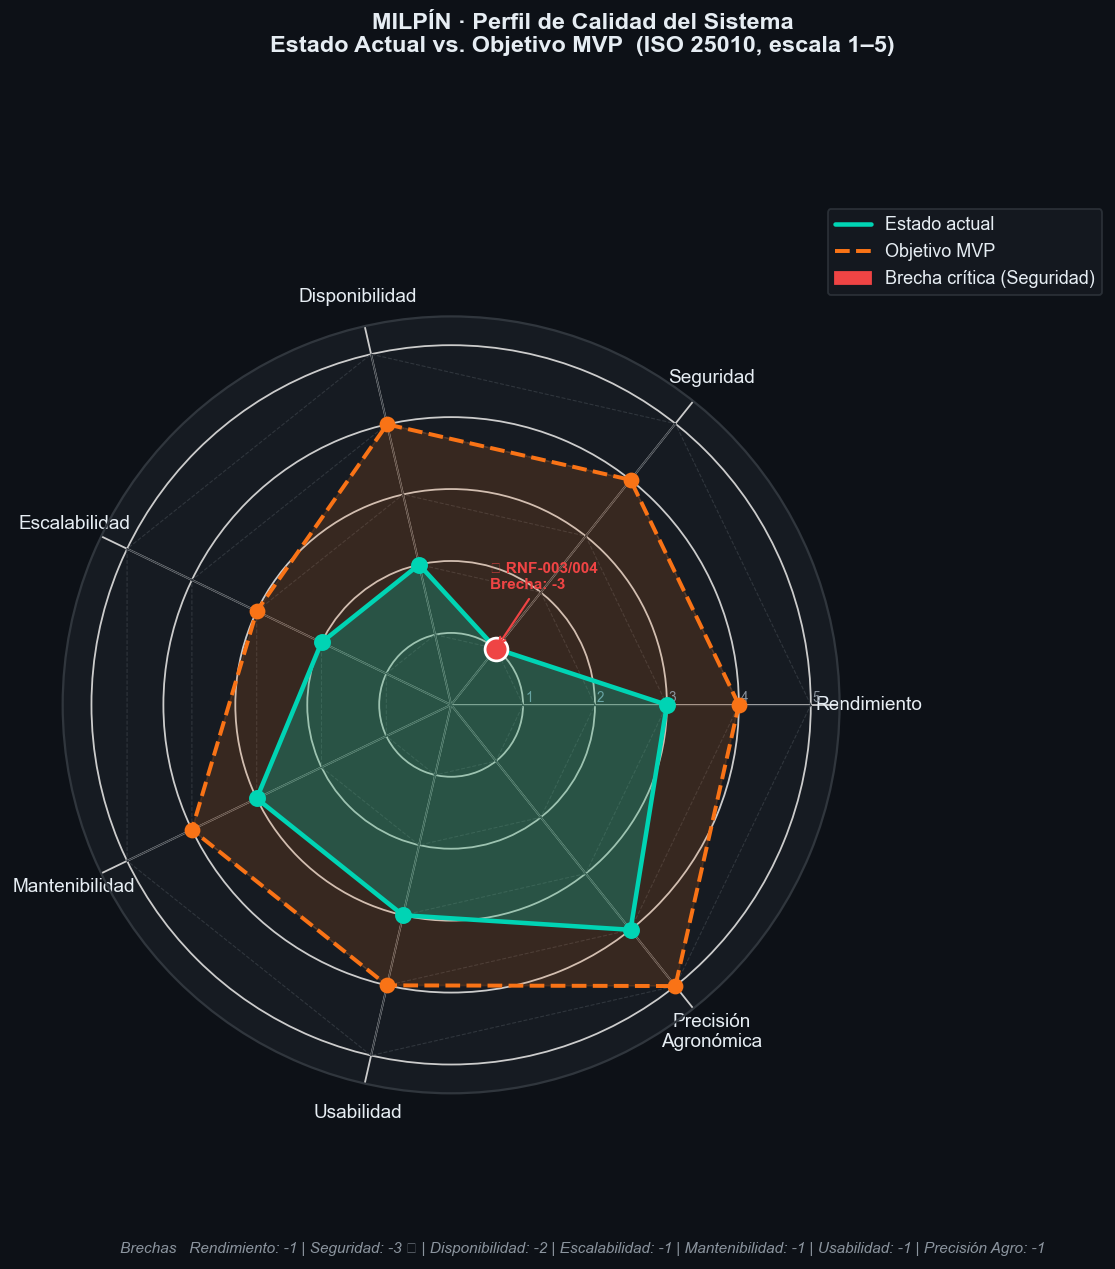

Radar guardado en radar_calidad_sistema.png


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 15 — Gráfico Radar: Perfil de Calidad del Sistema
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

DIMENSIONES = [
    "Rendimiento",
    "Seguridad",
    "Disponibilidad",
    "Escalabilidad",
    "Mantenibilidad",
    "Usabilidad",
    "Precisión\nAgronómica",
]
ACTUAL   = [3, 1, 2, 2, 3, 3, 4]
OBJETIVO = [4, 4, 4, 3, 4, 4, 5]

N = len(DIMENSIONES)
angles   = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles  += angles[:1]
actual   = ACTUAL   + ACTUAL[:1]
objetivo = OBJETIVO + OBJETIVO[:1]

BG       = "#0d1117"
BG_AX    = "#161b22"
GRID_CLR = "#30363d"
TXT      = "#e6edf3"
C_ACT    = "#00d4b4"
C_OBJ    = "#f97316"
C_ALERT  = "#ef4444"

fig, ax = plt.subplots(figsize=(9, 9),
                       subplot_kw=dict(polar=True),
                       facecolor=BG)
ax.set_facecolor(BG_AX)

# Anillos de referencia 1-5
for level in range(1, 6):
    ax.plot(angles, [level] * (N + 1), color=GRID_CLR,
            linewidth=0.6, linestyle="--", zorder=1)
    ax.text(0, level + 0.08, str(level),
            ha="center", va="bottom", fontsize=7.5, color="#8b949e")

# Radios
for angle in angles[:-1]:
    ax.plot([angle, angle], [0, 5], color=GRID_CLR, linewidth=0.8, zorder=1)

# Polígono Objetivo
ax.fill(angles, objetivo, color=C_OBJ, alpha=0.15, zorder=2)
ax.plot(angles, objetivo, color=C_OBJ, linewidth=2.2,
        linestyle="--", label="Objetivo MVP", zorder=3)
ax.scatter(angles[:-1], OBJETIVO, color=C_OBJ, s=60, zorder=4)

# Polígono Actual
ax.fill(angles, actual, color=C_ACT, alpha=0.25, zorder=5)
ax.plot(angles, actual, color=C_ACT, linewidth=2.5,
        label="Estado actual", zorder=6)
ax.scatter(angles[:-1], ACTUAL, color=C_ACT, s=70, zorder=7)

# Punto crítico Seguridad
idx_seg = 1
ax.scatter([angles[idx_seg]], [ACTUAL[idx_seg]],
           color=C_ALERT, s=160, zorder=8,
           edgecolors="white", linewidths=1.5)
ax.annotate(
    "⚠ RNF-003/004\nBrecha: -3",
    xy=(angles[idx_seg], ACTUAL[idx_seg]),
    xytext=(angles[idx_seg] + 0.35, ACTUAL[idx_seg] + 0.7),
    color=C_ALERT, fontsize=8.5, fontweight="bold",
    arrowprops=dict(arrowstyle="->", color=C_ALERT, lw=1.2),
    zorder=9
)

# Etiquetas
ax.set_xticks(angles[:-1])
ax.set_xticklabels(DIMENSIONES, color=TXT, fontsize=10.5)
ax.set_yticklabels([])
ax.set_ylim(0, 5.4)
ax.spines["polar"].set_color(GRID_CLR)

# Leyenda
alert_patch = mpatches.Patch(color=C_ALERT, label="Brecha crítica (Seguridad)")
ax.legend(
    handles=[
        plt.Line2D([0], [0], color=C_ACT,  linewidth=2.5, label="Estado actual"),
        plt.Line2D([0], [0], color=C_OBJ,  linewidth=2.2,
                   linestyle="--", label="Objetivo MVP"),
        alert_patch,
    ],
    loc="upper right", bbox_to_anchor=(1.35, 1.15),
    facecolor=BG_AX, edgecolor=GRID_CLR, labelcolor=TXT, fontsize=10
)

fig.suptitle(
    "MILP\u00cdN \u00b7 Perfil de Calidad del Sistema\n"
    "Estado Actual vs. Objetivo MVP  (ISO 25010, escala 1\u20135)",
    color=TXT, fontsize=13, fontweight="bold", y=1.02
)
fig.text(
    0.5, -0.04,
    "Brechas   Rendimiento: -1 | Seguridad: -3 \u26a0 | Disponibilidad: -2 | "
    "Escalabilidad: -1 | Mantenibilidad: -1 | Usabilidad: -1 | Precisi\u00f3n Agro: -1",
    ha="center", fontsize=8.5, color="#8b949e", style="italic"
)

plt.tight_layout()
plt.savefig("radar_calidad_sistema.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Radar guardado en radar_calidad_sistema.png")
